In [1]:
import requests
from tqdm import tqdm
from muon import MuData
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import mudata as md
# import shutil
import re

In [2]:
from oscb.data import DataLoader
from oscb.evaluator import eval, write_json
from oscb.utilization import Monitor

/opt/conda/lib/python3.11/site-packages/grakel/kernels/graph_hopper.py:9: PendingDeprecationWarning: Importing from numpy.matlib is deprecated since 1.19.0. The matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray. 
  from numpy.matlib import repmat


In [3]:
adata = DataLoader("CL-m-FACS_Bladder-1268-Tabula-2018", data_folder='/ps/downloads/')
adata

facs_Bladder_Seurat.h5ad: 23.3MB [00:00, 91.2MB/s]


File downloaded successfully to: downloads/facs_Bladder_Seurat.h5ad
benchmarksId: CL-m-FACS_Bladder-1268-Tabula-2018
adata_path: /usr/src/app/storage/Benchmarks/facsBladder_1755700462145/QC/facs_Bladder_Seurat.h5ad
datasetId: m-FACS_Bladder-1268-Tabula-2018
label: cell_ontology_class
metrics: ['ARI', 'Silhouette', 'NMI', 'Fowlkes Mallows']
task_type: Clustering


AnnData object with n_obs × n_vars = 1268 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nReads', 'plate.barcode', 'mouse.id', 'tissue', 'subtissue', 'FACS.selection', 'mouse.sex', 'percent.ercc', 'free_annotation', 'cell_ontology_class', 'percent.ribo', 'res.0.4', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_X_scVI', 'log1p', 'louvain', 'louvain_X_scVI', 'neighbors', 'pca'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

/tmp/ipykernel_2080/2023949081.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


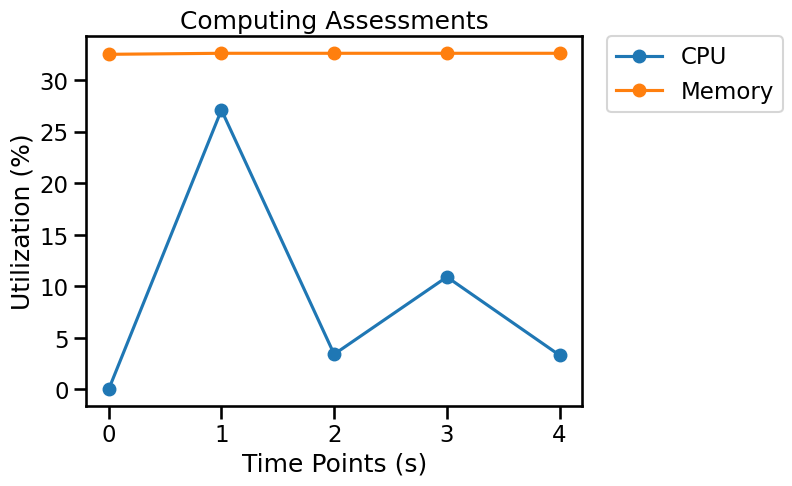

{'sys_info': {'CPU': 'x86_64 16-core @ 1.27 GHz',
  'RAM': '125.79 GB',
  'GPU': ['Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB']},
 'CPU': [0.0, 27.1, 3.4, 10.9, 3.3],
 'Memory': [32.5, 32.6, 32.6, 32.6, 32.6],
 'GPU': [0, 0, 0, 0, 0],
 'GPU Memory': [1.46, 1.46, 1.46, 1.46, 1.46],
 'time_points': [1758678573.1171024,
  1758678574.2672713,
  1758678575.4447289,
  1758678576.569928,
  1758678578.1120505]}

In [4]:
monitor = Monitor(1)
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)
sc.tl.leiden(adata)
monitor.stop()

Clustering Scores:
Silhouette: 0.7259
NMI: 0.5057
ARI: 0.2741
Fowlkes Mallows: 0.5239


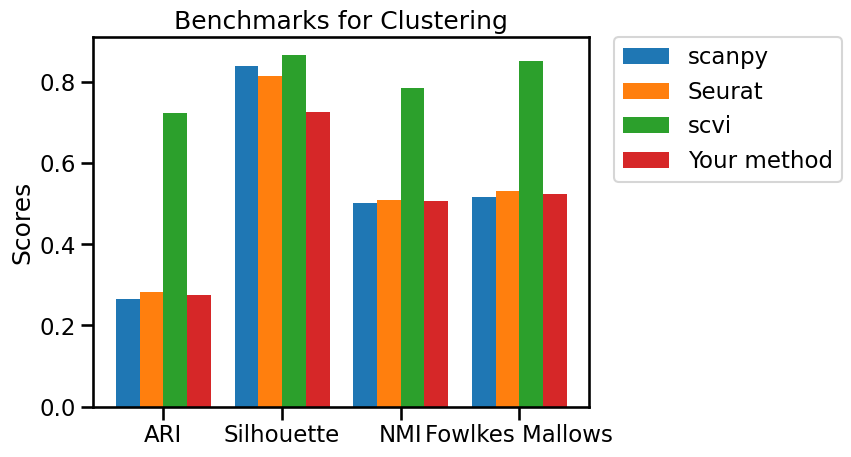

{'benchmarksId': 'CL-m-FACS_Bladder-1268-Tabula-2018',
 'datasetId': 'm-FACS_Bladder-1268-Tabula-2018',
 'task_type': 'Clustering',
 'tool': 'Your method',
 'Silhouette': 0.7259,
 'NMI': 0.5057,
 'ARI': 0.2741,
 'Fowlkes Mallows': 0.5239,
 'created_on': datetime.datetime(2025, 9, 23, 20, 49, 38, 307211)}

In [5]:
results = eval(adata, benchmarks_id="CL-m-FACS_Bladder-1268-Tabula-2018", cluster_key='leiden', embedding_key='X_umap')
results

In [6]:
write_json(results)

Dictionary successfully written to ./output.json


In [9]:
import json
from datetime import datetime

def serialize_datetime(obj):
    if isinstance(obj, datetime):
        return obj.isoformat()
    raise TypeError("Type not serializable")

In [10]:
def write_json(data, file_path="./output.json"):
    # Open the file in write mode ('w') and use json.dump() to write the dictionary
    with open(file_path, 'w') as json_file:
        json.dump(data, json_file, indent=4, default=serialize_datetime) # indent=4 for pretty-printing

    print(f"Dictionary successfully written to {file_path}")

# Imputation

In [ ]:
adata = DataLoader("IM-h-10x_PBMC-1087-10x-2017", data_folder='/ps/downloads/')
adata

In [ ]:
import scvi
# from scvi.model.utils import mde
import pymde

monitor = Monitor(1)
adata = adata.copy()
sys_info = monitor.get_sys_info()
scvi.model.SCVI.setup_anndata(adata)
model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 50, n_layers = 1, gene_likelihood = 'zinb')
model.train(max_epochs = 400, early_stopping = True)
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent
adata.layers["scvi_normalized"] = model.get_normalized_expression(
        library_size=10e4
    )
monitor.stop()

In [ ]:
results = eval(adata, benchmarks_id="IM-h-10x_PBMC-1087-10x-2017", denoised=adata.layers['scvi_normalized'])

In [ ]:
results = eval(adata, task="IM", denoised=adata.layers['scvi_normalized'])

# Batch Integration

In [4]:
adata = DataLoader("BI-h-PBMC-23589-Hao-2021", data_folder='/ps/downloads/')
adata

PBMC-23k_scanpy.h5ad: 247MB [00:01, 124MB/s]  


File downloaded successfully to: downloads/PBMC-23k_scanpy.h5ad
benchmarksId: BI-h-PBMC-23589-Hao-2021
label: labels
batch_key: batch
species: human
adata_path: /usr/src/app/storage/Benchmarks/PBMC-23k_1757033017651/QC/PBMC-23k_scanpy.h5ad
datasetId: h-PBMC-23589-Hao-2021
metrics: ['graph_conn', 'kBET', 'PCR_batch', 'ASW_label/batch', 'Biological Conservation']
task_type: Batch Integration


AnnData object with n_obs × n_vars = 23589 × 2000
    obs: 'batch', 'labels', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain', 'split_idx'
    var: 'gene_ids', 'gene_symbols', 'feature_types', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'louvain', 'neighbors', 'pca', 'scrublet'
    obsm: 'X_pca', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'logCP10K', 'raw_counts'
    obsp: 'connectiv

/opt/conda/lib/python3.11/site-packages/lightning/fabric/__init__.py:41: Deprecated call to `pkg_resources.declare_namespace('lightning.fabric')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
/opt/conda/lib/python3.11/site-packages/pkg_resources/__init__.py:2559: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('lightning')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(parent)
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/__init__.py:37: Deprecated call to `pkg_resources.declare_namespace('lightning.pytorch')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resourc

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


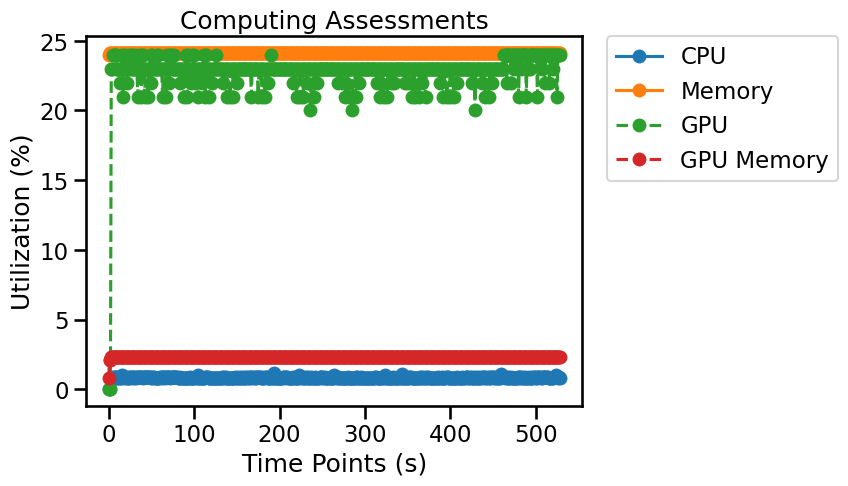

{'sys_info': {'CPU': 'x86_64 64-core @ 2.9 GHz',
  'RAM': '503.46 GB',
  'GPU': ['Tesla V100S-PCIE-32GB @ 32.0 GB',
   'Tesla V100S-PCIE-32GB @ 32.0 GB']},
 'CPU': [0.0,
  0.8,
  0.8,
  0.8,
  0.8,
  0.9,
  0.9,
  0.9,
  0.9,
  0.8,
  0.8,
  0.9,
  0.8,
  0.8,
  0.8,
  1.0,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.8,
  0.8,
  0.8,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.9,
  0.8,
  0.9,
  0.8,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.8,
  0.9,
  0.8,
  0.9,
  0.9,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.8,
  0.8,
  0.8,
  0.9,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.9,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.9,
  0.8,
  0.9,
  0.8,
  1.0,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.9,
  0.9,
  0.9,
  0.9,
  0.8,
  0.8,
  0.

In [5]:
# scVI imports
import scvi
# from scvi.model.utils import mde
import pymde

monitor = Monitor(1)
scvi.model.SCVI.setup_anndata(adata, categorical_covariate_keys = ['batch'], continuous_covariate_keys=['pct_counts_mt', 'pct_counts_ribo'])
model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 50, n_layers = 2, gene_likelihood = 'zinb')
model.train(max_epochs = 400, early_stopping = True)
monitor.stop()

In [7]:
adata_int = adata.copy()

In [8]:
adata = DataLoader("BI-h-PBMC-23589-Hao-2021", data_folder='/ps/downloads/')

PBMC-23k_scanpy.h5ad: 247MB [00:02, 117MB/s]  


File downloaded successfully to: downloads/PBMC-23k_scanpy.h5ad
benchmarksId: BI-h-PBMC-23589-Hao-2021
label: labels
batch_key: batch
species: human
adata_path: /usr/src/app/storage/Benchmarks/PBMC-23k_1757033017651/QC/PBMC-23k_scanpy.h5ad
datasetId: h-PBMC-23589-Hao-2021
metrics: ['graph_conn', 'kBET', 'PCR_batch', 'ASW_label/batch', 'Biological Conservation']
task_type: Batch Integration


Recompute neighbors on rep X_pca instead of None
Cluster for cluster_0.2 with leiden


/opt/conda/lib/python3.11/site-packages/scib/metrics/clustering.py:96: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...
PC regression...
cell cycle effect...


  0%|                                                                                                              | 0/3 [00:00<?, ?it/s]/opt/conda/lib/python3.11/site-packages/scanpy/tools/_score_genes.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(
/opt/conda/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)
/opt/conda/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable".

Isolated labels F1...
Isolated labels ASW...
Graph connectivity...
kBET...


...

/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages

Adding diffusion to step 4


/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/opt/conda/lib/python3.11/site-packages/scib/m

Adding diffusion to step 4
Adding diffusion to step 5


/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hvg_dir[i.obs[batch][0]] = i.var.index[hvg["highly_variable"]]
/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as posi

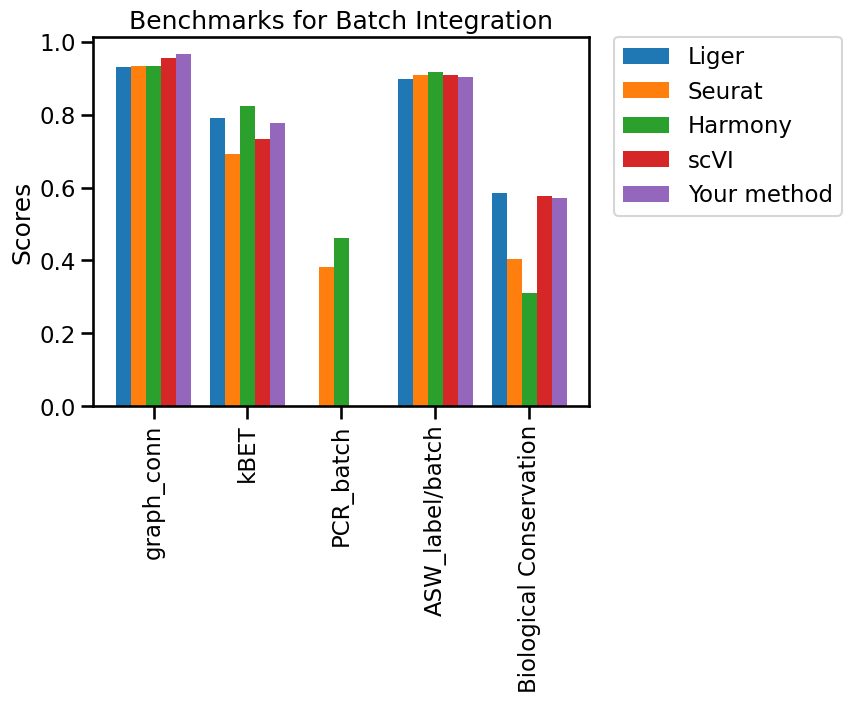

In [9]:
results = eval(adata, adata_int, benchmarks_id="BI-h-PBMC-23589-Hao-2021")

In [10]:
results

{'benchmarksId': 'BI-h-PBMC-23589-Hao-2021',
 'datasetId': 'h-PBMC-23589-Hao-2021',
 'task_type': 'Batch Integration',
 'tool': 'Your method',
 'created_on': datetime.datetime(2025, 10, 13, 23, 32, 17, 648078),
 'NMI_cluster/label': 0.7833,
 'ARI_cluster/label': 0.6631,
 'ASW_label': 0.5616,
 'ASW_label/batch': 0.9019,
 'PCR_batch': 0.0,
 'cell_cycle_conservation': 1.0,
 'isolated_label_F1': 0.0,
 'isolated_label_silhouette': 0.0,
 'graph_conn': 0.965,
 'kBET': 0.7756,
 'iLISI': 0.0,
 'cLISI': 0.0,
 'hvg_overlap': 1.0,
 'trajectory': 0.0,
 'Biological Conservation': 0.5726}

In [28]:
import matplotlib
import matplotlib.pyplot as plt

def plot_bars(task, labels, y_labels, data, tick_step=1, group_gap=0.2, bar_gap=0):
    x = np.arange(len(labels)) * tick_step
    group_num = len(data)
    group_width = tick_step - group_gap
    bar_span = group_width / group_num
    bar_width = bar_span - bar_gap
    for index, y in enumerate(data):
        plt.bar(x + index*bar_span, y, bar_width, label=y_labels[index])
    plt.ylabel('Scores')
    plt.title(f'Benchmarks for {task}')
    ticks = x + (group_width - bar_span) / 2
    plt.xticks(ticks, labels, rotation=90)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.show()

In [9]:
def get_bar_plot_data(benchmark_data, user_results=None):
    labels = benchmark_data[0]['x']
    y_labels = []
    data = []
    y_user = []
    
    # Add Benchmark data
    for i in range(len(benchmark_data)):
        data.append(benchmark_data[i]['y'])
        y_labels.append(benchmark_data[i]['name'])
    
    # Add user results
    if user_results is not None:    
        y_labels.append(user_results['tool'])
        for label in labels:
            y_user.append(user_results[label])
        data.append(y_user)

    return labels, y_labels, data

In [13]:
import requests
import json

server_endpoint = "http://clgpu018.clemson.cloudlab.us:5005/api/benchmarks/"
benchmarks_id = "BI-h-PBMC-23589-Hao-2021"
url = server_endpoint + benchmarks_id
response = requests.get(url)
benchmarks = response.json()
benchmarks
benchmarks_data = benchmarks['benchmarks_plot']['data']

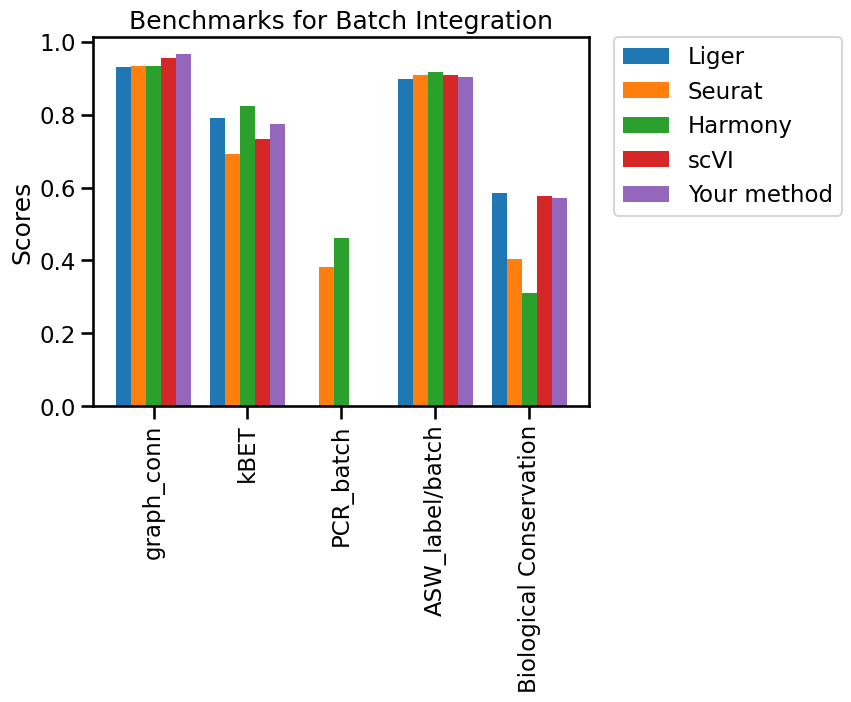

In [29]:
labels, y_labels, data = get_bar_plot_data(benchmarks_data, user_results=results)
plot_bars("Batch Integration", labels, y_labels, data)

In [30]:
adata_int

AnnData object with n_obs × n_vars = 23589 × 2000
    obs: 'batch', 'labels', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'cluster_0.2', 'cluster_0.4', 'cluster_0.6', 'cluster_0.8', 'cluster_1.0', 'cluster_1.2', 'cluster_1.4', 'cluster_1.6', 'cluster_1.8', 'cluster_2.0', 'cluster', 'silhouette_temp'
    var: 'gene_ids', 'gene_symbols', 'feature_types', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
   

In [11]:
results = eval(adata, adata_int, task="Batch Integration", batch_key="batch", label_key="labels", species="human")

/opt/conda/lib/python3.11/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.2 in adata.obs
  call_cluster_function(


Cluster for cluster_0.2 with leiden


/opt/conda/lib/python3.11/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.4 in adata.obs
  call_cluster_function(


Cluster for cluster_0.4 with leiden


/opt/conda/lib/python3.11/site-packages/scib/metrics/clustering.py:123: UserWarning: Overwriting existing key cluster_0.6 in adata.obs
  call_cluster_function(


...

/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages

Adding diffusion to step 4


/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:158: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/opt/conda/lib/python3.11/site-packages/scib/m

Adding diffusion to step 4
Adding diffusion to step 5


/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hvg_dir[i.obs[batch][0]] = i.var.index[hvg["highly_variable"]]
/opt/conda/lib/python3.11/site-packages/scib/metrics/highly_variable_genes.py:35: FutureWarning: Series.__getitem__ treating keys as posi

In [12]:
results

{'benchmarksId': None,
 'datasetId': None,
 'task_type': 'Batch Integration',
 'tool': 'Your method',
 'created_on': datetime.datetime(2025, 10, 13, 23, 36, 40, 759862),
 'NMI_cluster/label': 0.7833,
 'ARI_cluster/label': 0.6631,
 'ASW_label': 0.5616,
 'ASW_label/batch': 0.9019,
 'PCR_batch': 0.0,
 'cell_cycle_conservation': 1.0,
 'isolated_label_F1': 0.0,
 'isolated_label_silhouette': 0.0,
 'graph_conn': 0.965,
 'kBET': 0.7752,
 'iLISI': 0.0,
 'cLISI': 0.0,
 'hvg_overlap': 1.0,
 'trajectory': 0.0,
 'Biological Conservation': 0.5726}

# Multimodal Data Integration

In [3]:
mdata = DataLoader("MI-h-sci_CAR_Cell_Line-4739-Cao-2018", data_folder='/ps/downloads/')
mdata

sci-CAR_Cell_Lines_muon.h5mu: 1.04GB [00:12, 81.0MB/s]


File downloaded successfully to: downloads/sci-CAR_Cell_Lines_muon.h5mu
Benchmarks metadata:
benchmarksId: MI-h-sci_CAR_Cell_Line-4739-Cao-2018
species: human
datasetId: h-sci_CAR_Cell_Line-4739-Cao-2018
mod1: rna
mod2: atac
label: cell_type
batch_key: group
metrics: ['graph_conn', 'kBET', 'PCR_batch', 'ASW_label/batch', 'Biological Conservation']
task_type: Multimodal Data Integration


/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 1151 × 92524
  var:	'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'ensembl_ids'
  2 modalities
    rna:	1151 x 60550
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'ensembl_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap', 'var_names_all'
      obsm:	'X_pca', 'X_svd', 'X_umap', 'X_umap_3D', 'mode2'
      varm:	'PCs'
      layers:	'LogCP10K', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'
    atac:	1151 x 31974
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'hvg', 'leiden', 'log1p', 'neighbors', 'normalization_id', 'pca', 'umap'
      obsm:	'X_pca', 'X_svd', 'X_umap', 'X_umap_3D'
      varm:	'PCs'
      layers:	'LogCP10K', 'counts', 'normalized', 'raw_counts'
      obsp:	'connectivities', 'distances'

In [4]:
import os
import muon
import numpy as np
import scanpy as sc
from scipy.sparse import csr_matrix
import scvi
import seaborn as sns
import torch
import scipy
from scipy import sparse
import sys

/opt/conda/lib/python3.11/site-packages/lightning/fabric/__init__.py:41: Deprecated call to `pkg_resources.declare_namespace('lightning.fabric')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
/opt/conda/lib/python3.11/site-packages/pkg_resources/__init__.py:2559: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('lightning')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(parent)
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/__init__.py:37: Deprecated call to `pkg_resources.declare_namespace('lightning.pytorch')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resourc

/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/conda/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata

Training:   0%|          | 0/500 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/python3.11/site-packages/scvi/module/_multivae.py:874: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/opt/conda/lib/p

Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 5922.292. Signaling Trainer to stop.


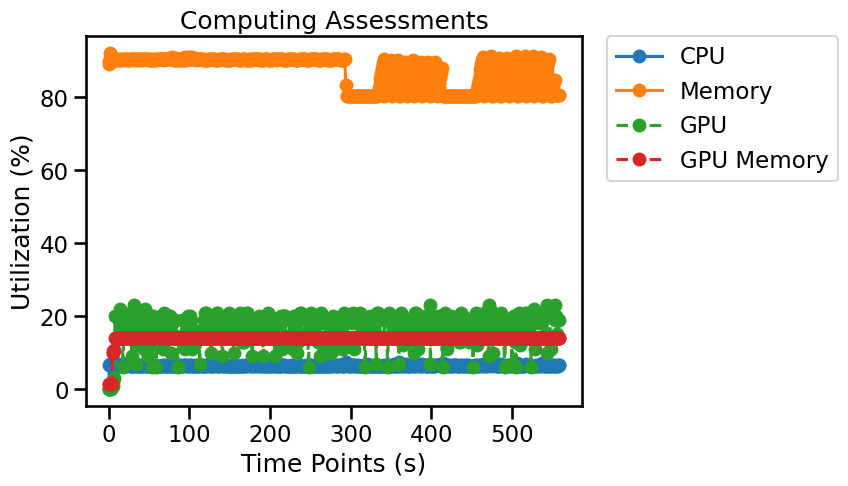

{'sys_info': {'CPU': 'x86_64 16-core @ 1.33 GHz',
  'RAM': '125.79 GB',
  'GPU': ['Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB']},
 'CPU': [0.0,
  6.7,
  6.9,
  6.6,
  6.4,
  6.1,
  6.3,
  6.4,
  6.4,
  6.6,
  6.5,
  6.5,
  7.0,
  6.6,
  6.5,
  6.4,
  6.6,
  6.6,
  6.6,
  6.5,
  6.5,
  6.9,
  6.5,
  6.9,
  6.6,
  6.6,
  6.5,
  6.6,
  6.5,
  6.4,
  6.5,
  6.6,
  6.5,
  7.0,
  6.4,
  6.5,
  6.6,
  6.5,
  6.5,
  6.5,
  6.4,
  6.5,
  6.5,
  6.6,
  6.9,
  6.5,
  6.4,
  6.6,
  6.4,
  6.4,
  6.5,
  6.4,
  6.6,
  6.4,
  6.6,
  6.6,
  6.4,
  6.5,
  6.5,
  6.4,
  6.4,
  6.5,
  6.5,
  6.5,
  6.4,
  6.5,
  6.5,
  6.6,
  6.5,
  6.7,
  6.5,
  6.5,
  6.5,
  6.4,
  6.4,
  6.5,
  6.6,
  6.5,
  6.5,
  6.5,
  6.4,
  6.5,
  6.5,
  6.6,
  6.7,
  6.5,
  6.5,
  6.6,
  6.5,
  6.6,
  6.5,
  6.5,
  6.5,
  6.6,
  6.6,
  6.6,
  6.5,
  6.6,
  6.5,
  6.5,
  6.5,
  6.6,
  6.6,
  6.5,
  6.4,
  6.5,
  6.4,
  6.6,
  6.4,
 

In [5]:
monitor = Monitor(1)

rna_subset="rna"
atac_subset="atac"

scvi.model.MULTIVI.setup_mudata(
    mdata,
    modalities={
        "rna_layer": rna_subset,
        "atac_layer": atac_subset,
    },
)

model = scvi.model.MULTIVI(
    mdata,
    n_genes=len(mdata.mod[rna_subset].var),
    n_regions=len(mdata.mod[atac_subset].var),
)

# For our sparse matrices, we want CSR rather than CSC as training will be faster
if type(mdata.mod[rna_subset].X) == scipy.sparse._csc.csc_matrix:
    mdata.mod[rna_subset].X = mdata.mod[rna_subset].X.tocsr()
elif type(mdata.mod[rna_subset].X) == np.matrix or type(mdata.mod[rna_subset].X) == np.ndarray:
    mdata.mod[rna_subset].X = sparse.csr_matrix(mdata.mod[rna_subset].X)
if type(mdata.mod[atac_subset].X) == scipy.sparse._csc.csc_matrix:
    mdata.mod[atac_subset].X = mdata.mod[atac_subset].X.tocsr()
elif type(mdata.mod[atac_subset].X) == np.matrix or type(mdata.mod[atac_subset].X) == np.ndarray:
    mdata.mod[atac_subset].X = sparse.csr_matrix(mdata.mod[atac_subset].X)
mdata.update()
model.train()

monitor.stop()

In [12]:
model.save("/ps/downloads/multivi", overwrite=True)

In [5]:
model = scvi.model.MULTIVI.load("/ps/downloads/multivi", adata=mdata)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /ps/downloads/multivi/model.pt already downloaded                                                    


/opt/conda/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/conda/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [6]:
MULTIVI_LATENT_KEY = "X_multivi"

mdata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(mdata, use_rep=MULTIVI_LATENT_KEY)
sc.tl.umap(mdata, min_dist=0.2)
mdata.obsm["MultiVI_imputed"] = model.get_normalized_expression()

/opt/conda/lib/python3.11/site-packages/oscb/evaluation/multimodal.py:21: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  scib_anndata.obs[f"{mod1}:{batch}"] = scib_anndata.obs[f"{mod1}:{batch}"].astype("category")
/opt/conda/lib/python3.11/site-packages/scib/metrics/clustering.py:96: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


Recompute neighbors on rep X_multivi instead of None
Cluster for cluster_0.2 with leiden
Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...
Isolated labels ASW...
Graph connectivity...


/opt/conda/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and 

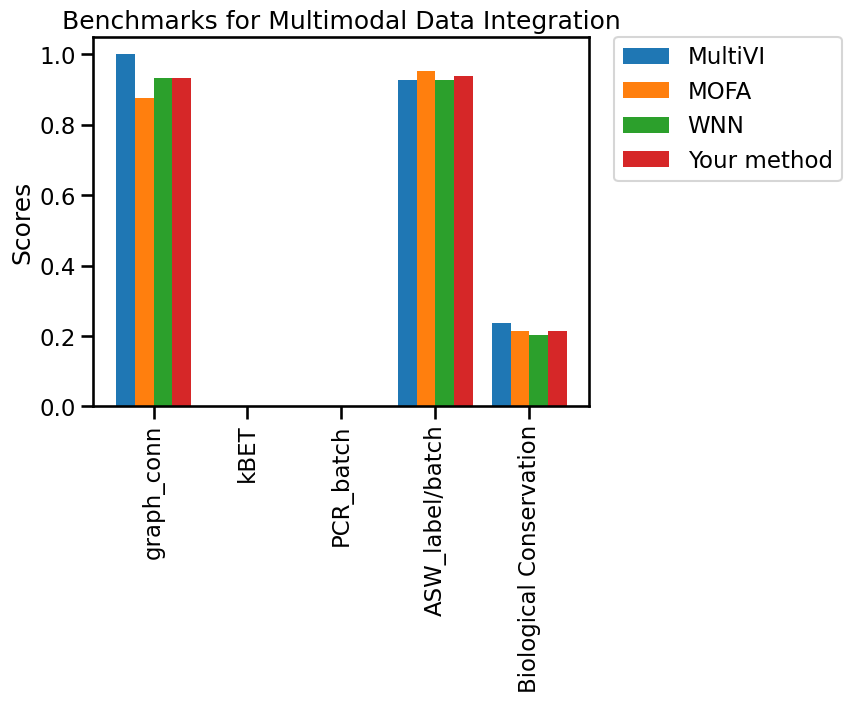

In [7]:
results = eval(mdata, mdata=mdata, embedding_key="X_multivi", benchmarks_id="MI-h-sci_CAR_Cell_Line-4739-Cao-2018")

In [10]:
results = eval(mdata, task="Multimodal Data Integration", mdata=mdata, embedding_key="X_multivi", mod1_key="rna", batch_key="group", label_key="cell_type", species="human")

/opt/conda/lib/python3.11/site-packages/oscb/evaluation/multimodal.py:21: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  scib_anndata.obs[f"{mod1}:{batch}"] = scib_anndata.obs[f"{mod1}:{batch}"].astype("category")


Recompute neighbors on rep X_multivi instead of None
Cluster for cluster_0.2 with leiden
Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...
Isolated labels ASW...
Graph connectivity...


/opt/conda/lib/python3.11/site-packages/scib/metrics/isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/opt/conda/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and 

In [11]:
results

{'benchmarksId': None,
 'datasetId': None,
 'task_type': 'Multimodal Data Integration',
 'tool': 'Your method',
 'created_on': datetime.datetime(2025, 10, 28, 0, 19, 29, 212307),
 'NMI_cluster/label': 0.1383,
 'ARI_cluster/label': 0.0573,
 'ASW_label': 0.6378,
 'ASW_label/batch': 0.9392,
 'PCR_batch': 0.0,
 'cell_cycle_conservation': 0.0,
 'isolated_label_F1': 0.0,
 'isolated_label_silhouette': 0.4539,
 'graph_conn': 0.9335,
 'kBET': 0.0,
 'iLISI': 0.0,
 'cLISI': 0.0,
 'hvg_overlap': 0.0,
 'trajectory': 0.0,
 'Biological Conservation': 0.2146}

In [14]:
mdata.mod

MuData
├─ rna AnnData (1151 x 60550)
└─ atac AnnData (1151 x 31974)

# Trajectory

In [3]:
adata = DataLoader("TJ-Planaria-Droplet_Planarian-18837-Mireya-2018", data_folder='/ps/downloads/')
adata

Planaria.h5ad: 35.3MB [00:01, 33.1MB/s]


File downloaded successfully to: downloads/Planaria.h5ad
Benchmarks metadata:
benchmarksId: TJ-Planaria-Droplet_Planarian-18837-Mireya-2018
label: labels
origin_group: origin_group
bm_traj: benchmark_traj
datasetId: Planaria-Droplet_Planarian-18837-Mireya-2018
metrics: ['Graph Edit Distance', 'Graph Kernel Score', 'Jaccard Similarity Coefficient', 'Tree Edit Distance', 'Mean']
task_type: Trajectory


AnnData object with n_obs × n_vars = 18837 × 2000
    obs: 'labels', 'leiden', 'louvain', 'split_idx'
    var: 'gene_ids', 'gene_symbols', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'benchmark_traj', 'hvg', 'leiden', 'log1p', 'louvain', 'neighbors', 'origin_group', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'connectivities', 'distances'

In [16]:
# !pip install celldiffusion

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [4]:
import torch
import scanpy as sc
import celldiffusion as cd

device = "cuda" if torch.cuda.is_available() else "cpu"

2025-10-29 10:25:18,396 - --------> Starting feature encoder ...
/opt/conda/lib/python3.11/site-packages/celldiffusion/diffusion/feature_encoder.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_1 = torch.tensor(feature_matrix.to(device), dtype = feature_matrix_recover.dtype)
2025-10-29 10:25:19,695 - ------------------------> Epoch: 1/2000, Current loss: 19358098.0000
2025-10-29 10:25:21,497 - ------------------------> Epoch: 51/2000, Current loss: 11502488.0000
2025-10-29 10:25:23,282 - ------------------------> Epoch: 101/2000, Current loss: 10705837.0000
2025-10-29 10:25:25,070 - ------------------------> Epoch: 151/2000, Current loss: 10298804.0000
2025-10-29 10:25:26,898 - ------------------------> Epoch: 201/2000, Current loss: 10104042.0000
2025-10-29 10:25:28,682 - ------------------------> Epoch: 251/2000, Current lo

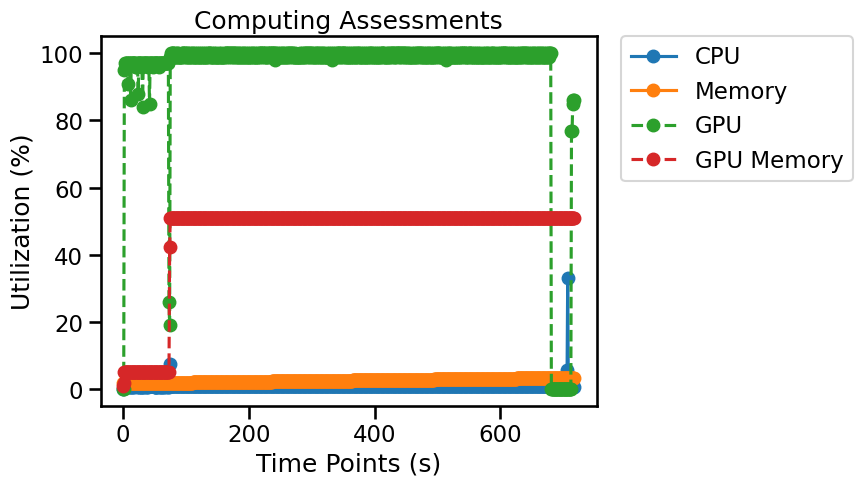

{'sys_info': {'CPU': 'x86_64 64-core @ 2.9 GHz',
  'RAM': '503.46 GB',
  'GPU': ['Tesla V100S-PCIE-32GB @ 32.0 GB',
   'Tesla V100S-PCIE-32GB @ 32.0 GB']},
 'CPU': [0.0,
  1.5,
  0.9,
  0.9,
  0.8,
  0.9,
  0.8,
  0.8,
  0.9,
  0.8,
  0.9,
  0.8,
  0.8,
  0.9,
  0.8,
  0.8,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.8,
  0.8,
  0.9,
  0.8,
  0.8,
  0.8,
  0.8,
  0.9,
  0.8,
  0.9,
  0.9,
  0.8,
  0.9,
  0.8,
  0.8,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.9,
  0.8,
  0.8,
  0.8,
  0.8,
  0.8,
  0.9,
  0.9,
  0.8,
  0.8,
  0.9,
  0.8,
  0.9,
  0.8,
  0.9,
  0.8,
  0.8,
  0.9,
  0.9,
  0.8,
  0.9,
  0.9,
  0.9,
  0.8,
  0.8,
  7.5,
  0.9,
  1.0,
  1.0,
  1.0,
  1.0,
  0.9,
  1.0,
  1.0,
  0.9,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.9,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.9,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.9,
  1.0,
  0.9,
  1.0,
  1.0,
  1.0,
  0.

In [5]:
monitor = Monitor(1)

cd.encode_features(adata, 
                   D_encode_list=[2000, 300, 50], # Encoder dimension in each layer
                   D_decode_list=[50, 300, 2000], # Decoder dimension in each layer
                   max_epoch=2000, # number of epoch
                   lr=1e-3,        # learning rate
                   device=device)

cd.util.evaluate_node_isolation(adata, use_rep='X_fae', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
                                predict_pct=0.15)  # Isolated nodes ratio.

# This graph provides the adjacency that will be used in loss function.
cd.graph.build_adj_graph(adata, 
                         use_rep='X_fae', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
                         k=50,            # K for building a KNN graph.
                         device=device)

# This graph is used in the graph neural diffusion process.
cd.graph.build_diffusion_graph(adata, 
                               use_rep='X_fae', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
                               k=50,            # K for building a KNN graph.
                               prune=False,     # If True, prune graph edges for isolated nodes.
                               device=device)

cd.graph_diffusion(adata, 
                   use_rep='X_fae', # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
                   max_epoch=2000,  # number of epoch
                   lr=1e-3,         # number of learning rate
                   time_increment_diffusion=0.2,  # Suggest value >0.0 & <=0.5. Larger value indicates stronger feature diffusion.
                   loss_adj=0.0,      # value 0 will recover the input data; value 1 will recover input KNN adjacency.
                   edge_rewire=False, # If True, rebuild KNN graph in each diffusion layer. Set as False to keep more inter-cluster relationships for trajectory inference and accelerate the training process.
                   device=device)
sc.pp.neighbors(adata, use_rep='X_dif', n_neighbors=50, n_pcs=50)
sc.tl.umap(adata)
cd.graph.build_graph(adata, use_rep="X_dif", k=50, device=device) # build KNN graph for clustering
cd.graph.call_attention(adata, device=device)  # generate cell-cell attention network

cd.anal.build_trajectory(adata, 
                     use_groups = 'labels',       # cell labels used to infer trajectory
                     origin_group = 'neoblast 1', # set the root cell label of trajectory
                     use_community=None,          # If None, use cell labels to build cell community.
                     use_rep = 'X_dif',           # The same as 'use_rep' in Scanpy. Choosing cell embeddings.
                     use_weights = 'attention',   # Using cell-cell attention information.
                     traj_shape='mdo_tree',       # Choose build-in tree shape trajectory inference method.
                     device=device,
                     save_csv = None)     # save trajectory into CSV file.

monitor.stop()

In [6]:
adata.uns['trajectory']

[('neoblast 1', 'epidermal neoblasts', 0.8293817),
 ('neoblast 1', 'gut progenitors', 1.0272104),
 ('neoblast 1', 'neural progenitors', 1.0388443),
 ('neoblast 1', 'pharynx cell type progenitors', 1.0966313),
 ('neoblast 1', 'parenchymal progenitors', 1.2227222),
 ('gut progenitors', 'goblet cells', 0.39986145),
 ('neoblast 1', 'secretory 3', 1.528513),
 ('neoblast 1', 'secretory 1', 1.5893692),
 ('pharynx cell type progenitors', 'pharynx cell type', 0.50047415),
 ('parenchymal progenitors', 'ldlrr-1+ parenchymal cells', 0.41024956),
 ('gut progenitors', 'phagocytes', 0.6295521),
 ('neoblast 1', 'secretory 4', 1.7115308),
 ('neoblast 1', 'protonephridia', 1.7699767),
 ('neural progenitors', 'cav-1+ neurons', 0.7574751),
 ('neoblast 1', 'muscle progenitors', 1.8084893),
 ('secretory 3', 'secretory 2', 0.29807082),
 ('neural progenitors', 'npp-18+ neurons', 0.7911296),
 ('neural progenitors', 'ChAT neurons 1', 0.8477064),
 ('epidermal neoblasts', 'early epidermal progenitors', 1.0717887)

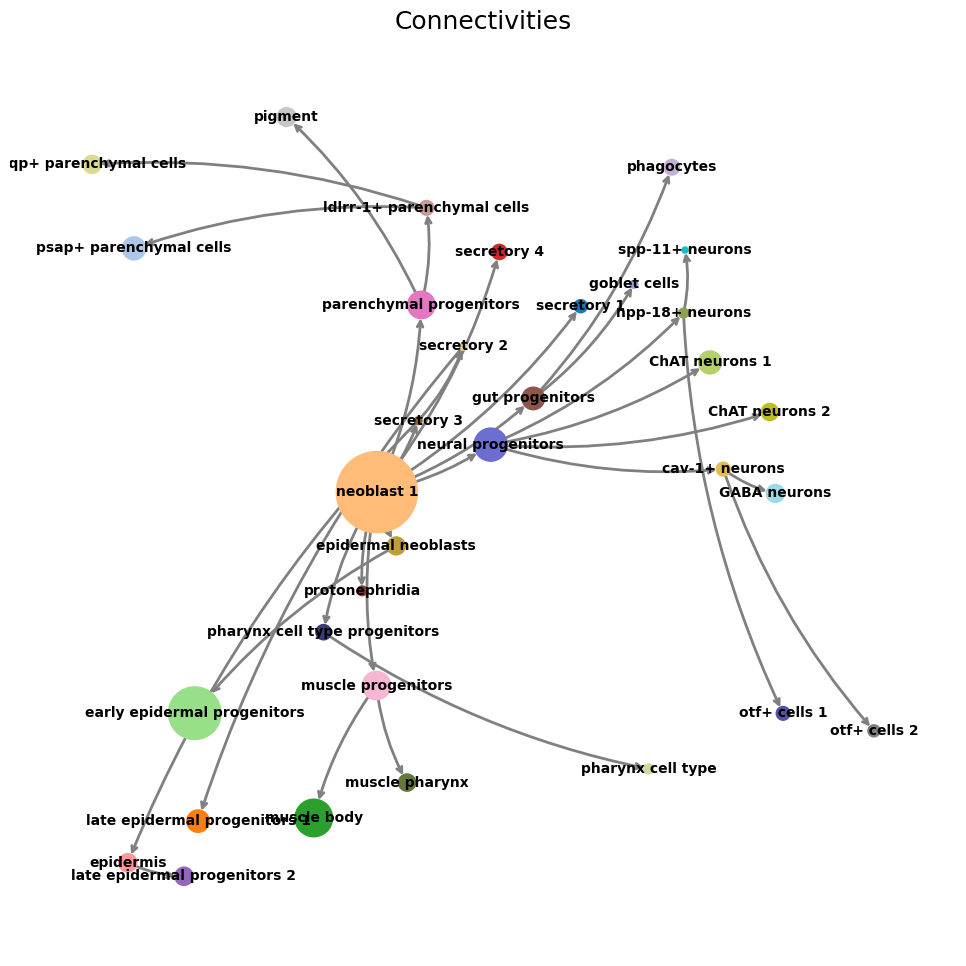

In [7]:
# Use points to represent cell types in UMAP plot.
cd.anal.community_umap(adata, use_umap = 'X_umap')

cd.anal.plot_trajectory(adata, 
                        node_scale = 10000, 
                        node_color = None,
                        edge_width=2, 
                        edge_color='gray', 
                        figsize=(10, 10), 
                        font_size=10, 
                        font_weight='bold',
                        title='Connectivities',
                        save_fig=None)

In [9]:
# adata.write_h5ad('./tj.h5ad', compression='gzip')

In [3]:
adata = sc.read_h5ad('./tj.h5ad')
adata

AnnData object with n_obs × n_vars = 18837 × 2000
    obs: 'labels', 'leiden', 'louvain', 'split_idx', 'isolation'
    var: 'gene_ids', 'gene_symbols', 'feature_types', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'adj_edge_index', 'adjusted_attention', 'attention', 'benchmark_traj', 'community', 'connectivities', 'diffusion_edge_index', 'edge_index', 'gnd_state_dict', 'graph_diffusion_args', 'hvg', 'leiden', 'log1p', 'louvain', 'neighbors', 'origin_group', 'pca', 'trajectory', 'umap'
    obsm: 'X_dif', 'X_fae', 'X_pca', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'connectivities', 'distances'

In [14]:
type(adata.uns['trajectory']) == np.ndarray

True

In [10]:
import numpy as np
import pandas as pd

df_tj = pd.DataFrame(adata.uns['trajectory'], columns=['from', 'to', 'length'])
df_tj

,from,to,length
0,neoblast 1,epidermal neoblasts,0.8293817
1,neoblast 1,gut progenitors,1.0272104
2,neoblast 1,neural progenitors,1.0388443
3,neoblast 1,pharynx cell type progenitors,1.0966313
4,neoblast 1,parenchymal progenitors,1.2227222
5,gut progenitors,goblet cells,0.39986145
6,neoblast 1,secretory 3,1.528513
7,neoblast 1,secretory 1,1.5893692
8,pharynx cell type progenitors,pharynx cell type,0.50047415
9,parenchymal progenitors,ldlrr-1+ parenchymal cells,0.41024956


In [7]:
type(adata.uns['benchmark_traj'])

pandas.core.frame.DataFrame

In [8]:
adata.uns['benchmark_traj']

,from,to,length,directed
1,neoblast 1,epidermal neoblasts,1,True
2,epidermal neoblasts,early epidermal progenitors,1,True
3,early epidermal progenitors,late epidermal progenitors 1,1,True
4,late epidermal progenitors 1,late epidermal progenitors 2,1,True
5,late epidermal progenitors 2,epidermis,1,True
6,neoblast 1,parenchymal progenitors,1,True
7,parenchymal progenitors,pigment,1,True
8,parenchymal progenitors,aqp+ parenchymal cells,1,True
9,parenchymal progenitors,psap+ parenchymal cells,1,True
10,parenchymal progenitors,ldlrr-1+ parenchymal cells,1,True


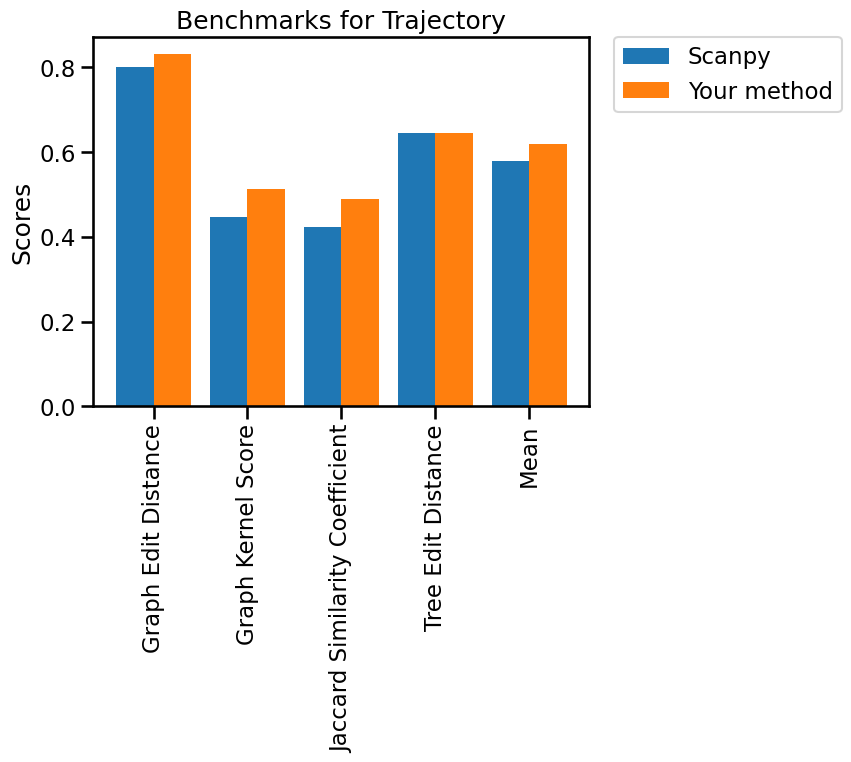

In [15]:
results = eval(adata, benchmarks_id="TJ-Planaria-Droplet_Planarian-18837-Mireya-2018", traj=df_tj)

In [12]:
results = eval(adata, task="Trajectory", traj=df_tj, bm_traj=adata.uns['benchmark_traj'], root_node=adata.uns['origin_group'])

In [13]:
results

{'benchmarksId': None,
 'datasetId': None,
 'task_type': 'Trajectory',
 'tool': 'Your method',
 'Graph Edit Distance': 0.8308,
 'Graph Kernel Score': 0.5133,
 'Jaccard Similarity Coefficient': 0.4884,
 'Tree Edit Distance': 0.6452,
 'Mean': 0.6194,
 'created_on': datetime.datetime(2025, 10, 29, 10, 53, 35, 780250)}

# Cell-Cell Comunication

In [3]:
adata = DataLoader("CCC-m-10x_Brain-14249-Tasic-2016", data_folder='/ps/downloads/')
adata

Mouse_brain_atlas_scanpy.h5ad: 391MB [00:04, 97.5MB/s] 


File downloaded successfully to: downloads/Mouse_brain_atlas_scanpy.h5ad
Benchmarks metadata:
benchmarksId: CCC-m-10x_Brain-14249-Tasic-2016
label: label
ccc_target: ccc_target
species: mouse
datasetId: m-10x_Brain-14249-Tasic-2016
metrics: ['Precision-recall AUC', 'Odds Ratio']
task_type: Cell-Cell Communication


AnnData object with n_obs × n_vars = 14249 × 3000
    obs: 'label', 'sizeFactor', 'subclass', 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain', 'split_idx'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_from_cache', 'age_days', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'ccc_target', 'class', 'cluster', 'cluster_correlation', 'complexity_cg', 'confusion_score', 'core_intermediate_call', 'donor', 'driver_line

In [11]:
adata.X.todense()
adata.raw = adata.copy()

In [8]:
import numpy as np
import liana as li
import scanpy as sc
from liana.mt import rank_aggregate
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [9]:
def run_liana_ccc(adata, cell_type_label, species, methods=[], aggregate_methods=['rra']):
    resource_name = 'consensus'
    if species == "mouse":
        resource_name = "mouseconsensus"
            
    # run cellphonedb
    # cellphonedb(adata,
    #         groupby=cell_type_label, 
    #         # NOTE by default the resource uses HUMAN gene symbols
    #         resource_name='consensus',
    #         expr_prop=0.1,
    #         verbose=True, key_added='cpdb_res')

    # by default, liana's output is saved in place:
    # adata.uns['cpdb_res'].head()

    if "CellPhoneDB" in methods:
        cellphonedb(adata,
            groupby=cell_type_label, 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name=resource_name,
            expr_prop=0.1,
            verbose=True, 
            key_added="CellPhoneDB")
        # Filter & Re-order
        adata.uns["CellPhoneDB"]["score"] = adata.uns["CellPhoneDB"].apply(
            lambda x: _p_filt(x.cellphone_pvals, x["lr_means"]), axis=1)

    if "SingleCellSignalR" in methods:
        singlecellsignalr(adata,
            groupby=cell_type_label, 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name=resource_name,
            expr_prop=0.1,
            verbose=True, 
            key_added='SingleCellSignalR')
        adata.uns["SingleCellSignalR"]["score"] = adata.uns["SingleCellSignalR"]["lrscore"]

    if "Connectome" in methods:
        connectome(adata,
            groupby=cell_type_label, 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name=resource_name,
            expr_prop=0.1,
            verbose=True, 
            key_added="Connectome")
        adata.uns["Connectome"]["score"] = adata.uns["Connectome"]["scaled_weight"]

    if "NATMI" in methods:
        natmi(adata,
            groupby=cell_type_label, 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name=resource_name,
            expr_prop=0.1,
            verbose=True, 
            key_added="NATMI")
        adata.uns["NATMI"]["score"] = adata.uns["NATMI"]["spec_weight"]

    if "log2FC" in methods:
        logfc(adata,
            groupby=cell_type_label, 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name=resource_name,
            expr_prop=0.1,
            verbose=True, 
            key_added="log2FC")
        adata.uns["log2FC"]["score"] = adata.uns["log2FC"]["lr_logfc"]
        adata.uns["log2FC"]['score'] = adata.uns["log2FC"]['score'].replace([-np.inf], 0)
        adata.uns["log2FC"]['score'] = adata.uns["log2FC"]['score'].replace([np.inf], 1)

    if "CellChat" in methods:
        cellchat(adata,
            groupby=cell_type_label, 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name=resource_name,
            expr_prop=0.1,
            verbose=True, 
            key_added="CellChat")
        # Filter & Re-order
        adata.uns["CellChat"]["score"] = adata.uns["CellChat"].apply(
            lambda x: _p_filt(x.cellchat_pvals, x["lr_probs"]), axis=1)
        
    if "GeometricMean" in methods:
        geometric_mean(adata,
            groupby=cell_type_label, 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name=resource_name,
            expr_prop=0.1,
            verbose=True, 
            key_added="GeometricMean")
        # Filter & Re-order
        adata.uns["GeometricMean"]["score"] = adata.uns["GeometricMean"].apply(
            lambda x: _p_filt(x.gmean_pvals, x["lr_gmeans"]), axis=1)
    
    # Run rank_aggregate
    for method in aggregate_methods:
        li.mt.rank_aggregate(adata, 
                            groupby=cell_type_label,
                            resource_name=resource_name,
                            expr_prop=0.1,
                            aggregate_method=method,
                            verbose=True, 
                            key_added=f"LIANA ({method})")
        adata.uns[f"LIANA ({method})"]["score"] = adata.uns[f"LIANA ({method})"]["lrscore"]
        adata.uns[f"LIANA ({method})"]["ligand"] = adata.uns[f"LIANA ({method})"]["ligand_complex"]

    # adata.uns['liana_res'].head()

    # methods = [logfc, geometric_mean]
    # new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)
    # new_rank_aggregate(adata,
    #                 groupby='bulk_labels',
    #                 expr_prop=0.1, 
    #                 verbose=True,
    #                 # Note that with this option, we don't perform permutations
    #                 # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
    #                 n_perms=None,
    #                 use_raw=True,
    #                 )
    
    # adata.uns['liana_res'].head()

    return adata


# Helper function to filter according to permutation p-values
def _p_filt(x, y):
    if x <= 0.05:
        return y
    else:
        return 0

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features
Assuming that counts were `natural` log-normalized!


/opt/conda/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:360: RuntimeWarning: overflow encountered in power
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:

Running CellPhoneDB


100%|███████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 96.93it/s]


Running Connectome
Running log2FC


/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce


Running NATMI
Running SingleCellSignalR


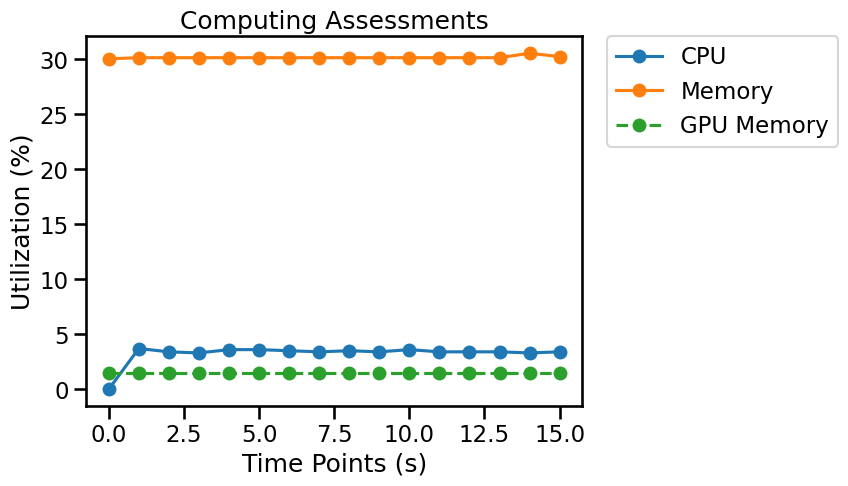

{'sys_info': {'CPU': 'x86_64 16-core @ 1.32 GHz',
  'RAM': '125.79 GB',
  'GPU': ['Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB']},
 'CPU': [0.0,
  3.7,
  3.4,
  3.3,
  3.6,
  3.6,
  3.5,
  3.4,
  3.5,
  3.4,
  3.6,
  3.4,
  3.4,
  3.4,
  3.3,
  3.4],
 'Memory': [30.0,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.1,
  30.5,
  30.2],
 'GPU': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'GPU Memory': [1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46,
  1.46],
 'time_points': [1761883542.0427108,
  1761883543.1535115,
  1761883544.2818432,
  1761883545.4151528,
  1761883546.5823054,
  1761883547.7017028,
  1761883548.8109422,
  1761883549.9191492,
  1761883551.026319,
  1761883552.1351044,
  1761883553.2427878,
  1761883554.3776543,
  1761883555.4867682,
  176188355

In [12]:
monitor = Monitor(1)
adata = run_liana_ccc(adata, cell_type_label='label', species='mouse', methods=[], aggregate_methods=['rra'])
monitor.stop()

In [24]:
adata.uns['LIANA (rra)'][['source', 'target', 'score']].head()

,source,target,score
19478,Vip,Endo,0.996298
19422,Vip,CR,0.995611
20024,Vip,SMC,0.990857
19541,Vip,L4,0.990529
19787,Vip,Macrophage,0.990097


In [25]:
adata.uns['LIANA (rra)'][['ligand', 'target', 'score']].head()

,ligand,target,score
19478,Vip,Endo,0.996298
19422,Vip,CR,0.995611
20024,Vip,SMC,0.990857
19541,Vip,L4,0.990529
19787,Vip,Macrophage,0.990097


In [19]:
adata.uns['ccc_target']

,source,target,response
0,CR,Astro,0
1,Endo,Astro,1
2,L2.3.IT,Astro,0
3,L4,Astro,0
4,L5.IT,Astro,0
...,...,...,...
501,Serpinf1,VLMC,0
502,SMC,VLMC,0
503,Sncg,VLMC,0
504,Sst,VLMC,0


In [18]:
type(adata.uns['LIANA (rra)'])

pandas.core.frame.DataFrame

/opt/conda/lib/python3.11/site-packages/oscb/evaluation/ccc.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.002707032486796157' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.


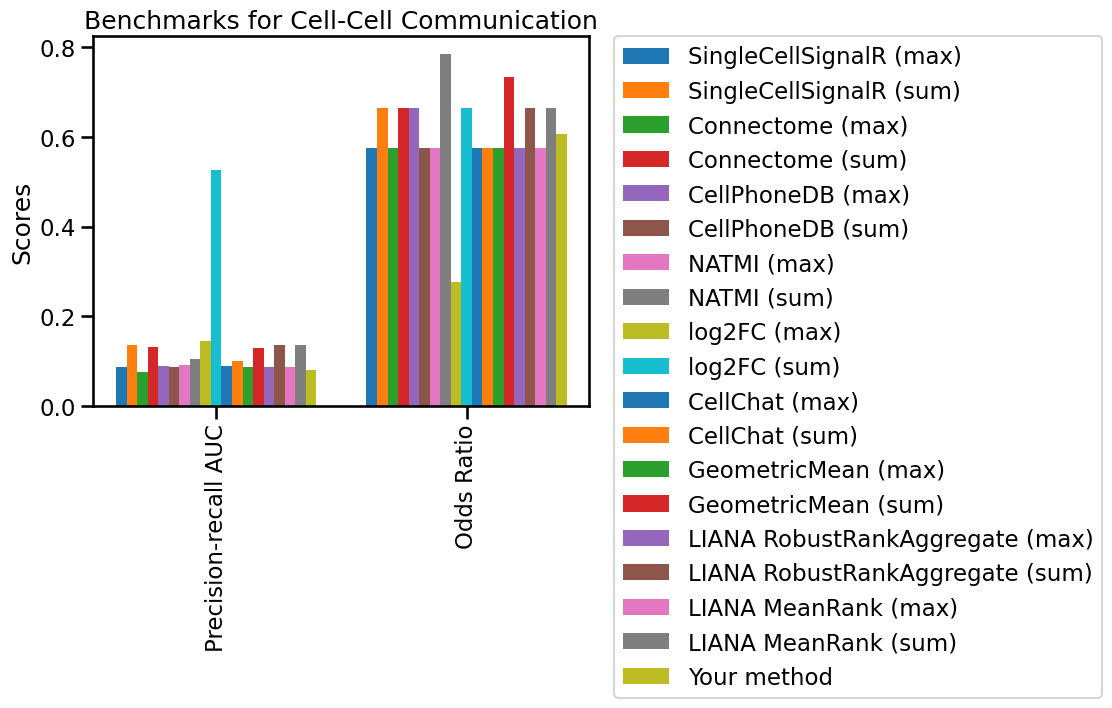

{'benchmarksId': 'CCC-m-10x_Brain-14249-Tasic-2016',
 'datasetId': 'm-10x_Brain-14249-Tasic-2016',
 'task_type': 'Cell-Cell Communication',
 'tool': 'Your method',
 'Precision-recall AUC': 0.0801,
 'Odds Ratio': 0.606,
 'created_on': datetime.datetime(2025, 10, 30, 23, 10, 2, 509021)}

In [15]:
results = eval(adata, benchmarks_id="CCC-m-10x_Brain-14249-Tasic-2016", ccc_pred=adata.uns['LIANA (rra)'])
results

In [17]:
results = eval(adata, task="Cell-Cell Communication", ccc_pred=adata.uns['LIANA (rra)'], ccc_target=adata.uns['ccc_target'])
results

/opt/conda/lib/python3.11/site-packages/oscb/evaluation/ccc.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.002707032486796157' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.


{'benchmarksId': None,
 'datasetId': None,
 'task_type': 'Cell-Cell Communication',
 'tool': 'Your method',
 'Precision-recall AUC': 0.0801,
 'Odds Ratio': 0.606,
 'created_on': datetime.datetime(2025, 10, 30, 23, 14, 16, 365856)}

In [20]:
bdata = DataLoader("CCC-h-Breast_Cancer-42512-Wu,-2021", data_folder='/ps/downloads/')
bdata

Triple_negative_breast_cancer_atlas_scanpy.h5ad: 409MB [00:04, 97.0MB/s] 


File downloaded successfully to: downloads/Triple_negative_breast_cancer_atlas_scanpy.h5ad
Benchmarks metadata:
benchmarksId: CCC-h-Breast_Cancer-42512-Wu,-2021
label: label
ccc_target: ccc_target
species: human
datasetId: h-Breast_Cancer-42512-Wu,-2021
metrics: ['Precision-recall AUC', 'Odds Ratio']
task_type: Cell-Cell Communication


AnnData object with n_obs × n_vars = 42512 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'ident', 'label', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain', 'split_idx'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'ccc_target', 'hvg', 'leiden', 'ligand_receptor_resource', 'log1p', 'louvain', 'merge_keys', 'neighbors', 'pca', 'scrublet', 

In [21]:
bdata.uns['ccc_target']

,ligand,target,response
0,BDNF,B.cells.Memory,0
1,BMP2,B.cells.Memory,0
2,BMP4,B.cells.Memory,0
3,BMP6,B.cells.Memory,0
4,CXCL12,B.cells.Memory,0
...,...,...,...
807,OSM,T.cells.CD8,0
808,TGFB1,T.cells.CD8,0
809,TGFB3,T.cells.CD8,0
810,VEGFA,T.cells.CD8,0


# Cell Type Annotation

In [36]:
adata = DataLoader("CT-h-PBMC-11989-Adam-2022", data_folder='/ps/downloads/')
adata

PBMC7K_annotation_1_scanpy.h5ad: 198MB [00:02, 74.4MB/s] 


File downloaded successfully to: downloads/PBMC7K_annotation_1_scanpy.h5ad
Benchmarks metadata:
benchmarksId: CT-h-PBMC-11989-Adam-2022
label: labels
datasetId: h-PBMC-11989-Adam-2022
metrics: ['Accuracy', 'F1_macro', 'F1_micro', 'F1_weighted']
task_type: Cell Type Annotation


AnnData object with n_obs × n_vars = 11989 × 2000
    obs: 'batch', 'labels', 'split_idx', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain'
    var: 'ensembl_ids', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'louvain', 'neighbors', 'pca', 'scrublet'
    obsm: 'X_pca', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'logCP10K', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [37]:
import scvi
import scanpy as sc
import numpy as np

In [38]:
train_adata = adata[adata.obs.split_idx.str.contains('train'), :].copy()
test_adata = adata[adata.obs.split_idx.str.contains('test'), :].copy()
train_adata

AnnData object with n_obs × n_vars = 4008 × 2000
    obs: 'batch', 'labels', 'split_idx', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain'
    var: 'ensembl_ids', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'louvain', 'neighbors', 'pca', 'scrublet'
    obsm: 'X_pca', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'logCP10K', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [41]:
def scanvi_transfer(adata, refs = None, ref_adata = None, labels = None):
    if refs is not None and labels is not None:
        adata.obs['CellType'] = 'Unknown'
        adata.obs['Batch'] = 'Unknown'
        sc.pp.filter_genes(adata, min_cells = 10)
        adatas = [load_anndata(input) for input in refs]
        dater = sc.concat(adatas, join='outer')
        sc.pp.filter_genes(dater, min_cells = 10)
        dater = dater[~dater.obs[labels].isna()]
        dater = reset_x_to_raw(dater)
        dater.obs['CellType'] = dater.obs[labels]
        dater.obs['Batch'] = 'reference'
        dater = sc.concat((adata, dater))
        dater.obs['Sample'] = dater.obs.index

        sc.pp.highly_variable_genes(dater, flavor = 'seurat_v3', n_top_genes=3000, batch_key="Batch", subset = True)
        scvi.model.SCVI.setup_anndata(dater, batch_key='Batch', categorical_covariate_keys = ['Sample'])
        vae = scvi.model.SCVI(dater)
        vae.train(max_epochs = 400, early_stopping = True)

        lvae = scvi.model.SCANVI.from_scvi_model(vae, adata = dater, unlabeled_category = 'Unknown',
                                            labels_key = 'CellType')

        lvae.train(max_epochs=20, n_samples_per_label=100)

        dater.obs['scANVI_predicted'] = lvae.predict(dater)
        dater.obs['scANVI_transfer_score'] = lvae.predict(soft = True).max(axis = 1)
        dater = dater[dater.obs.Batch == 'Unknown']

        adata.obs = adata.obs.merge(right = dater.obs[['scANVI_predicted', 'scANVI_transfer_score']], left_index=True, right_index=True)
        adata.obs = adata.obs.drop('CellType', axis=1)

    elif ref_adata is not None and labels is not None:
        adata.obs['CellType'] = 'Unknown'
        adata.obs['Batch'] = 'Unknown'
        sc.pp.filter_genes(adata, min_cells = 10)

        dater = ref_adata
        sc.pp.filter_genes(dater, min_cells = 10)
        dater = dater[~dater.obs[labels].isna()]
        dater.obs['CellType'] = dater.obs[labels]
        dater.obs['Batch'] = 'reference'
        dater = sc.concat((adata, dater))
        dater.obs['Sample'] = dater.obs.index

        sc.pp.highly_variable_genes(dater, flavor = 'seurat_v3', n_top_genes=3000, batch_key="Batch", subset = True)
        scvi.model.SCVI.setup_anndata(dater, batch_key='Batch', categorical_covariate_keys = ['Sample'])
        vae = scvi.model.SCVI(dater)
        vae.train(max_epochs = 400, early_stopping = True)

        lvae = scvi.model.SCANVI.from_scvi_model(vae, adata = dater, unlabeled_category = 'Unknown',
                                            labels_key = 'CellType')

        lvae.train(max_epochs=20, n_samples_per_label=100)

        dater.obs['scANVI_predicted'] = lvae.predict(dater)
        dater.obs['scANVI_transfer_score'] = lvae.predict(soft = True).max(axis = 1)
        dater = dater[dater.obs.Batch == 'Unknown']

        adata.obs = adata.obs.merge(right = dater.obs[['scANVI_predicted', 'scANVI_transfer_score']], left_index=True, right_index=True)
        adata.obs = adata.obs.drop('CellType', axis=1)
    else:
        print(f"scANVI annotation is failed due to empty user reference or cell labels ({labels}).")

    return adata

INFO: Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 710.828. Signaling Trainer to stop.
INFO     Training for 20 epochs.                                                                                   


INFO: Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Training:   0%|          | 0/20 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
`Trainer.fit` stopped: `max_epochs=20` reached.


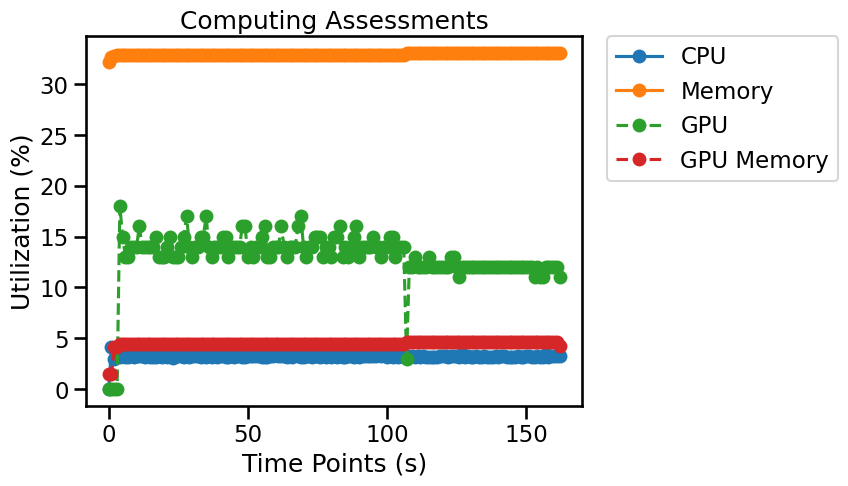

{'sys_info': {'CPU': 'x86_64 16-core @ 1.33 GHz',
  'RAM': '125.79 GB',
  'GPU': ['Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB',
   'Tesla V100-SXM2-16GB @ 16.0 GB']},
 'CPU': [0.0,
  4.2,
  3.0,
  3.2,
  3.2,
  3.3,
  3.2,
  3.2,
  3.4,
  3.2,
  3.3,
  3.3,
  3.3,
  3.2,
  3.3,
  3.2,
  3.2,
  3.2,
  3.3,
  3.2,
  3.4,
  3.2,
  3.4,
  3.1,
  3.3,
  3.3,
  3.3,
  3.2,
  3.3,
  3.2,
  3.3,
  3.3,
  3.3,
  3.2,
  3.3,
  3.2,
  3.3,
  3.2,
  3.3,
  3.2,
  3.3,
  3.3,
  3.2,
  3.2,
  3.3,
  3.2,
  3.3,
  3.5,
  3.2,
  3.2,
  3.3,
  3.3,
  3.3,
  3.3,
  3.3,
  3.2,
  3.2,
  3.2,
  3.3,
  3.3,
  3.4,
  3.3,
  3.3,
  3.3,
  3.2,
  3.3,
  3.2,
  3.4,
  3.3,
  3.2,
  3.2,
  3.3,
  3.3,
  3.2,
  3.3,
  3.3,
  3.2,
  3.3,
  3.2,
  3.4,
  3.2,
  3.3,
  3.2,
  3.3,
  3.2,
  3.2,
  3.3,
  3.3,
  3.2,
  3.3,
  3.2,
  3.3,
  3.3,
  3.3,
  3.3,
  3.3,
  3.3,
  3.4,
  3.3,
  3.4,
  3.2,
  3.3,
  3.2,
  3.3,
  3.2,
  3.3,
  3.2,
  3.3,
  3.2,
 

In [42]:
monitor = Monitor(1)
adata = scanvi_transfer(test_adata, ref_adata=train_adata, labels="labels")
monitor.stop()

In [43]:
adata.obs

,batch,labels,split_idx,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,...,outlier,doublet_score,predicted_doublet,clf_doublet,clf_score,leiden,louvain,Batch,scANVI_predicted,scANVI_transfer_score
AAACCTGAGCTAGTGG-1,batch_0,CD4 T cells,test,432,432,6.070738,1573.0,7.361375,48.378894,0.0,...,False,0.049483,False,0.0,1.578277e-21,3,3,Unknown,CD4 T cells,0.936056
AAACCTGCACATTAGC-1,batch_0,CD4 T cells,test,297,297,5.697093,892.0,6.794587,50.448430,0.0,...,False,0.083395,False,0.0,5.619940e-43,0,0,Unknown,CD4 T cells,0.893613
AAACCTGCACTGTTAG-1,batch_0,CD14+ Monocytes,test,509,509,6.234411,1389.0,7.237059,32.253420,0.0,...,False,0.087719,False,0.0,1.342605e-01,1,1,Unknown,CD14+ Monocytes,0.985149
AAACCTGCATAGTAAG-1,batch_0,CD14+ Monocytes,test,500,500,6.216606,1487.0,7.305188,38.533961,0.0,...,False,0.089992,False,0.0,6.997719e-17,1,1,Unknown,CD14+ Monocytes,0.996089
AAACCTGCATGAACCT-1,batch_0,CD8 T cells,test,412,412,6.023448,948.0,6.855409,31.223629,0.0,...,False,0.114574,False,0.0,7.233285e-19,4,4,Unknown,CD8 T cells,0.966353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCATGTCCC-1,batch_0,CD4 T cells,test,372,372,5.921578,1005.0,6.913737,45.174129,0.0,...,False,0.087719,False,0.0,9.566734e-12,0,0,Unknown,CD4 T cells,0.810946
TTTGTCATCCGATATG-1,batch_0,CD4 T cells,test,445,445,6.100319,1707.0,7.443079,54.422964,0.0,...,False,0.031901,False,0.0,9.725695e-14,0,0,Unknown,CD4 T cells,0.981760
TTTGTCATCGTCTGAA-1,batch_0,CD14+ Monocytes,test,578,578,6.361302,1913.0,7.556951,36.173549,0.0,...,False,0.117867,False,0.0,1.251942e-01,1,1,Unknown,CD14+ Monocytes,0.986452
TTTGTCATCTCGAGTA-1,batch_0,CD4 T cells,test,414,414,6.028279,1189.0,7.081708,43.229605,0.0,...,False,0.060938,False,0.0,1.299134e-25,0,3,Unknown,CD4 T cells,0.694920


Encode labels
Compute prediction accuracy
Compute F1 score


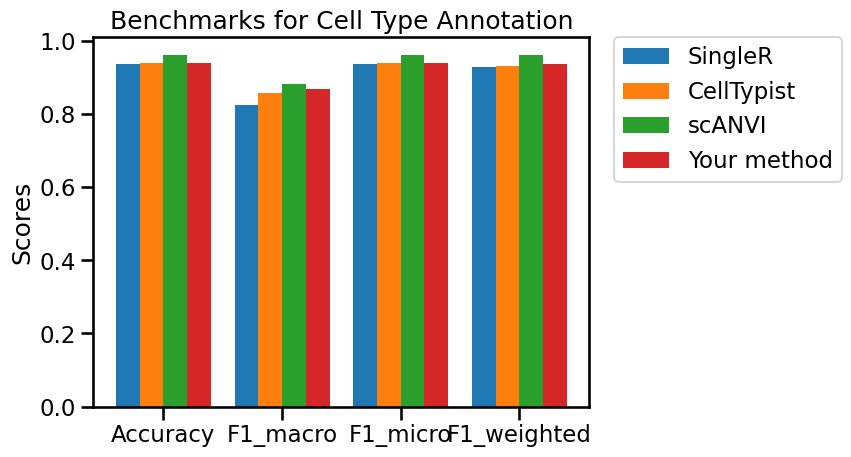

{'benchmarksId': 'CT-h-PBMC-11989-Adam-2022',
 'datasetId': 'h-PBMC-11989-Adam-2022',
 'task_type': 'Cell Type Annotation',
 'tool': 'Your method',
 'Accuracy': 0.9386,
 'F1_macro': 0.869,
 'F1_micro': 0.9386,
 'F1_weighted': 0.9379,
 'created_on': datetime.datetime(2025, 10, 31, 23, 48, 50, 310271)}

In [45]:
results = eval(adata, benchmarks_id="CT-h-PBMC-11989-Adam-2022", labels_pred=adata.obs['scANVI_predicted'])
results

In [47]:
results = eval(task="Cell Type Annotation", labels=adata.obs['labels'], labels_pred=adata.obs['scANVI_predicted'])
results

Encode labels
Compute prediction accuracy
Compute F1 score


{'benchmarksId': None,
 'datasetId': None,
 'task_type': 'Cell Type Annotation',
 'tool': 'Your method',
 'Accuracy': 0.9386,
 'F1_macro': 0.869,
 'F1_micro': 0.9386,
 'F1_weighted': 0.9379,
 'created_on': datetime.datetime(2025, 10, 31, 23, 50, 35, 188897)}

In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad('/usr/src/app/storage/Benchmarks/dropletHeart_1755575390051/QC/droplet_Heart_Seurat.h5ad')
adata

AnnData object with n_obs × n_vars = 523 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'cell_ontology_class', 'res.0.5', 'cluster.ids', 'cell_ontology_id', 'subsetA', 'subsetA_cluster.ids', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_X_scVI', 'log1p', 'louvain', 'louvain_X_scVI', 'neighbors', 'pca'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [3]:
adata.X

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.7181669, 0.7181669, 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [4.195974 , 0.7738907, 4.2134094, ..., 0.       , 0.       ,
        0.       ]], dtype=float32)

In [15]:
adata.layers['raw_counts']

array([[  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       ...,
       [  1.,   1.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [112.,   2., 114., ...,   0.,   0.,   0.]], dtype=float32)

In [3]:
bdata = sc.read_h5ad('/usr/src/app/storage/Benchmarks/dropletHeart_1755575390051/QC/results/0fc871cc00756dfdbaf8567e46cfbb7b/droplet_Heart_DESeq2.h5ad')
bdata

AnnData object with n_obs × n_vars = 523 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nCounts_RNA', 'nFeatures_RNA', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'cell_ontology_class', 'res.0.5', 'cluster.ids', 'cell_ontology_id', 'subsetA', 'subsetA_cluster.ids', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'DESeq2_leiden', 'DESeq2_louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'DESeq2_leiden', 'DESeq2_louvain', 'neighbors'
    obsm: 'DESeq2_pca', 'DESeq2_tsne', 'DESeq2_tsne_3D', 'DESeq2_umap', 'DESeq2_umap_3D'
    layers: 'DESeq2', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [5]:
bdata.obs.DESeq2_leiden

10X_P7_4_AAACCTGCACGACGAA    0
10X_P7_4_AAACCTGGTTCCACGG    1
10X_P7_4_AAACCTGTCTCGATGA    2
10X_P7_4_AAAGCAAAGTGAATTG    1
10X_P7_4_AAAGCAACACCGAAAG    2
                            ..
10X_P7_4_TTTGGTTCAGACTCGC    3
10X_P7_4_TTTGTCAAGTGGAGAA    3
10X_P7_4_TTTGTCACAAGCCATT    4
10X_P7_4_TTTGTCAGTCGATTGT    2
10X_P7_4_TTTGTCAGTGCGCTTG    2
Name: DESeq2_leiden, Length: 523, dtype: category
Categories (6, object): ['0', '1', '2', '3', '4', '5']

In [6]:
bdata.obs.leiden

10X_P7_4_AAACCTGCACGACGAA    0
10X_P7_4_AAACCTGGTTCCACGG    2
10X_P7_4_AAACCTGTCTCGATGA    0
10X_P7_4_AAAGCAAAGTGAATTG    1
10X_P7_4_AAAGCAACACCGAAAG    3
                            ..
10X_P7_4_TTTGGTTCAGACTCGC    4
10X_P7_4_TTTGTCAAGTGGAGAA    4
10X_P7_4_TTTGTCACAAGCCATT    3
10X_P7_4_TTTGTCAGTCGATTGT    5
10X_P7_4_TTTGTCAGTGCGCTTG    2
Name: leiden, Length: 523, dtype: category
Categories (7, object): ['0', '1', '2', '3', '4', '5', '6']

In [7]:
'DESeq2_leiden' in bdata.obs.columns

True

In [17]:
bdata.X.todense()

matrix([[ 0.,  1.,  0., ...,  0.,  0.,  1.],
        [ 0.,  1.,  0., ...,  1.,  1.,  0.],
        [34.,  1.,  0., ...,  1.,  0.,  0.],
        ...,
        [ 0.,  1.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  1.],
        [ 0.,  3.,  0., ...,  0.,  0.,  0.]])

In [9]:
bdata.obsm['DESeq2_umap_3D']

array([[ 2.0761745, 12.018357 ,  5.1405373],
       [ 8.790813 , -2.3958726,  4.965977 ],
       [ 2.5588198, 10.84109  ,  5.758694 ],
       ...,
       [ 6.2033186,  7.9555354,  6.0501323],
       [ 2.8368437, 10.362061 ,  4.9986935],
       [ 4.775708 ,  8.996723 ,  5.1181073]], dtype=float32)

In [18]:
bdata.layers['DESeq2']

array([[ 1.02683744,  2.05367489,  1.02683744, ...,  1.02683744,
         1.02683744,  2.05367489],
       [ 1.01953769,  2.03907537,  1.01953769, ...,  2.03907537,
         2.03907537,  1.01953769],
       [35.660816  ,  2.03776091,  1.01888046, ...,  2.03776091,
         1.01888046,  1.01888046],
       ...,
       [ 1.03042266,  2.06084532,  1.03042266, ...,  1.03042266,
         1.03042266,  1.03042266],
       [ 1.02274111,  1.02274111,  1.02274111, ...,  1.02274111,
         1.02274111,  2.04548221],
       [ 1.02958161,  4.11832642,  1.02958161, ...,  1.02958161,
         1.02958161,  1.02958161]])

In [7]:
bdata.layers['raw_counts'].todense()

matrix([[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  1.,   1.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [112.,   2., 114., ...,   0.,   0.,   0.]])

In [2]:
import numpy as np

In [20]:
np.sum(np.isinf(bdata.layers['DESeq2']))

0

In [21]:
np.sum(np.isinf(bdata.obsm['DESeq2_pca']))

0

In [1]:
import scanpy as sc
from anndata import AnnData

In [2]:
adata =sc.read_h5ad("/usr/src/app/storage/Benchmarks/facsKidney_1755709836242/QC/facs_Kidney_Seurat.h5ad")
adata.obs

,orig.ident,n_counts,n_genes,nReads,plate.barcode,mouse.id,tissue,subtissue,FACS.selection,mouse.sex,...,seurat_clusters,doublet_score,doublet_class,leiden,louvain,split_idx,_scvi_batch,_scvi_labels,leiden_X_scVI,louvain_X_scVI
A10.B002775.3_39_F.1.1,Kidney,240236.0,259,1059637.0,B002775,3_39_F,Kidney,,Viable,F,...,0,0.161290,Singlet,1,0,test,0,0,1,1
A10.MAA000752.3_10_M.1.1,Kidney,80776.0,231,409127.0,MAA000752,3_10_M,Kidney,,Viable,M,...,0,0.161290,Singlet,1,0,test,0,0,1,1
A11.MAA000801.3_11_M.1.1,Kidney,68362.0,105,340318.0,MAA000801,3_11_M,Kidney,,Viable,M,...,2,0.096774,Singlet,2,2,test,0,0,2,2
A12.MAA000801.3_11_M.1.1,Kidney,116405.0,115,495057.0,MAA000801,3_11_M,Kidney,,Viable,M,...,6,0.112903,Singlet,3,4,test,0,0,2,2
A13.B001717.3_38_F.1.1,Kidney,146791.0,302,725921.0,B001717,3_38_F,Kidney,,Viable,F,...,0,0.241935,Singlet,2,6,test,0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P4.MAA000801.3_11_M.1.1,Kidney,380523.0,373,1263701.0,MAA000801,3_11_M,Kidney,,Viable,M,...,5,0.258065,Singlet,5,7,test,0,0,3,3
P5.MAA000545.3_8_M.1.1,Kidney,78858.0,198,337524.0,MAA000545,3_8_M,Kidney,,Viable,M,...,3,0.209677,Singlet,4,5,test,0,0,0,0
P6.MAA000801.3_11_M.1.1,Kidney,166246.0,275,663581.0,MAA000801,3_11_M,Kidney,,Viable,M,...,0,0.129032,Singlet,1,0,test,0,0,1,1
P8.MAA000752.3_10_M.1.1,Kidney,70688.0,148,305049.0,MAA000752,3_10_M,Kidney,,Viable,M,...,2,0.145161,Singlet,2,2,test,0,0,2,2


In [3]:
adata.obs.columns[adata.obs.columns.duplicated()]

Index([], dtype='object')

In [5]:
def make_unique(cols):
    import collections
    counts = collections.defaultdict(int)
    for i, col in enumerate(cols):
        counts[col] += 1
        if counts[col] > 1:
            cols[i] = f"{col}_{counts[col]-1}"
    return cols

adata.obs.columns = make_unique(adata.obs.columns.tolist())

In [23]:
def run_clustering(adata, layer=None, use_rep=None, resolution=0.5, random_state=0, skip_if_exist=False, fig_path=None):
    if layer == "Pearson_residuals":
        print("Normalize Pearson_residuals may create NaN values, which are not accepted by PCA.")
        return adata
    
    if fig_path is not None:
        if layer is None:
            fig_path = os.path.join(fig_path, 'leiden_clustering.png')
        else:
            fig_path = os.path.join(fig_path, layer+'_leiden_clustering.png')

    if skip_if_exist:
        if layer is not None and layer + '_louvain' in adata.obs.keys() and  layer + '_leiden' in adata.obs.keys():
            return adata
        elif layer is None and use_rep is not None and use_rep + '_louvain' not in adata.obs.keys() and use_rep + '_leiden' not in adata.obs.keys():
            return adata
        elif layer is None and 'louvain' not in adata.obs.keys() and 'leiden' not in adata.obs.keys():
            return adata
    
    if layer is not None: # and layer + '_louvain' not in adata.obs.keys():
        adata_temp = adata.copy()
        adata_temp.X = adata_temp.layers[layer]
        
        # Clustering the neighborhood graph
        sc.tl.leiden(adata_temp, resolution=resolution, 
                    random_state=random_state, n_iterations=3)
        # Save the Clustering plot
        if fig_path is not None:
            sc.pl.embedding(adata_temp, basis=layer+'_umap', color='leiden', show=False)
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')

        adata.uns[layer + '_leiden'] = adata_temp.uns["leiden"].copy()
        adata.obs[layer + '_leiden'] = adata_temp.obs["leiden"].copy()

        sc.tl.louvain(adata_temp)
        adata.uns[layer + '_louvain'] = adata_temp.uns["louvain"].copy()
        adata.obs[layer + '_louvain'] = adata_temp.obs["louvain"].copy()
        adata_temp = None
    elif layer is None and use_rep is not None: # and use_rep + '_louvain' not in adata.obs.keys():
        leiden_key = "leiden_" + use_rep
        louvain_key = "louvain_" + use_rep
        sc.tl.leiden(adata, key_added = leiden_key, resolution=resolution, 
                    random_state=random_state, n_iterations=3)
        
        # Save the Clustering plot
        if fig_path is not None:
            sc.pl.umap(adata, color=leiden_key, show=False)
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')

        sc.tl.louvain(adata, key_added = louvain_key)
    elif layer is None: # and 'louvain' not in adata.obs.keys():
        # Clustering the neighborhood graph
        leiden_key = "leiden"
        louvain_key = "louvain"

        if not is_normalized(adata.X, 200):
            adata.layers['raw_counts'] = adata.X.copy()
            sc.pp.normalize_total(adata)
            sc.pp.log1p(adata)

        sc.tl.leiden(adata, key_added = leiden_key, resolution=resolution, 
                    random_state=random_state, n_iterations=3)
        # Save the Clustering plot
        if fig_path is not None:
            sc.pl.umap(adata, color=leiden_key, show=False)
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')

        sc.tl.louvain(adata, key_added = louvain_key)
    # else:
    #     if layer is None: layer = 'X'
    #     print(f"Cluster for {layer} already exists, skipped.")

    return adata

In [24]:
bdata = run_clustering(bdata, layer='DESeq2', resolution=0.5)

In [25]:
bdata

AnnData object with n_obs × n_vars = 2559 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nCounts_RNA', 'nFeatures_RNA', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'cell_ontology_class', 'res.0.5', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'DESeq2_leiden', 'DESeq2_louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'DESeq2_leiden', 'DESeq2_louvain', 'neighbors'
    obsm: 'DESeq2_pca', 'DESeq2_tsne', 'DESeq2_tsne_3D', 'DESeq2_umap', 'DESeq2_umap_3D'
    layers: 'DESeq2', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [26]:
adata_temp = bdata.copy()
adata_temp.X = adata_temp.layers['DESeq2']

# Clustering the neighborhood graph
sc.tl.leiden(adata_temp, resolution=0.5, 
            random_state=0, n_iterations=3)

In [27]:
adata_temp

AnnData object with n_obs × n_vars = 2559 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nCounts_RNA', 'nFeatures_RNA', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'cell_ontology_class', 'res.0.5', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'DESeq2_leiden', 'DESeq2_louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'DESeq2_leiden', 'DESeq2_louvain', 'neighbors', 'leiden'
    obsm: 'DESeq2_pca', 'DESeq2_tsne', 'DESeq2_tsne_3D', 'DESeq2_umap', 'DESeq2_umap_3D'
    layers: 'DESeq2', 'raw_counts'
    obsp: 'connectivities', 'distances'

<Axes: title={'center': 'DESeq2_leiden'}, xlabel='DESeq2_umap1', ylabel='DESeq2_umap2'>

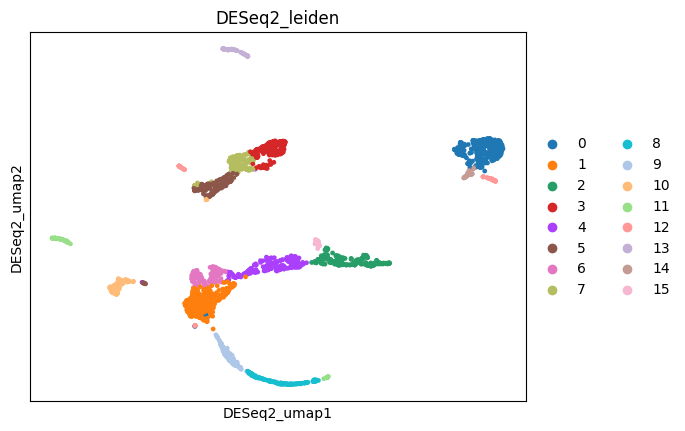

In [29]:
sc.pl.embedding(adata_temp, basis='DESeq2_umap', color='DESeq2_leiden', show=False)

In [15]:
bdata

AnnData object with n_obs × n_vars = 523 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nCounts_RNA', 'nFeatures_RNA', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'cell_ontology_class', 'res.0.5', 'cluster.ids', 'cell_ontology_id', 'subsetA', 'subsetA_cluster.ids', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'DESeq2_leiden', 'DESeq2_louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'DESeq2_leiden', 'DESeq2_louvain', 'neighbors'
    obsm: 'DESeq2_pca', 'DESeq2_tsne', 'DESeq2_tsne_3D', 'DESeq2_umap', 'DESeq2_umap_3D'
    layers: 'DESeq2', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [8]:
from vitessce.data_utils import optimize_adata

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [9]:
bdata = optimize_adata(
        bdata,
        obs_cols = ['cell_ontology_class', 'DESeq2_leiden'], # Add your "hue" columns here
        obsm_keys = ['DESeq2_umap'],             # Add your UMAP key
    )

In [10]:
bdata

AnnData object with n_obs × n_vars = 523 × 2000
    obs: 'cell_ontology_class', 'DESeq2_leiden'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    obsm: 'DESeq2_umap'
    layers: 'DESeq2', 'raw_counts'

In [11]:
bdata.write_zarr("./bdata.zarr", chunks=(bdata.n_obs, bdata.n_vars))

In [4]:
bdata

AnnData object with n_obs × n_vars = 523 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nCounts_RNA', 'nFeatures_RNA', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'cell_ontology_class', 'res.0.5', 'cluster.ids', 'cell_ontology_id', 'subsetA', 'subsetA_cluster.ids', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'DESeq2_leiden', 'DESeq2_louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'DESeq2_leiden', 'DESeq2_louvain', 'neighbors'
    obsm: 'DESeq2_pca', 'DESeq2_tsne', 'DESeq2_tsne_3D', 'DESeq2_umap', 'DESeq2_umap_3D'
    layers: 'DESeq2', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [7]:
bdata.obs['orig.ident'].values

['10X', '10X', '10X', '10X', '10X', ..., '10X', '10X', '10X', '10X', '10X']
Length: 523
Categories (1, object): ['10X']

In [9]:
bdata.obs['batch'] = "10X"
bdata.obs['batch'] = bdata.obs['batch'].astype("category")
bdata.obs['batch'].values

['10X', '10X', '10X', '10X', '10X', ..., '10X', '10X', '10X', '10X', '10X']
Length: 523
Categories (1, object): ['10X']

In [3]:
bdata.obs['batch'] = bdata.obs['orig.ident'].values
bdata.obs["batch"] = bdata.obs["batch"].astype("category")
bdata.obs['batch'].values

['10X', '10X', '10X', '10X', '10X', ..., '10X', '10X', '10X', '10X', '10X']
Length: 523
Categories (1, object): ['10X']

In [1]:
import torch
import os
import numpy as np
import pandas as pd
import scanpy as sc
from typing import Tuple

# scVI imports
import scvi
# from scvi.model.utils import mde
import pymde

import seaborn as sns
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

/opt/conda/lib/python3.11/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.6.2 is installed, but it is not compatible with the installed jaxlib version 0.6.1, so it will not be used.
  warnings.warn(


In [2]:
bdata = sc.read_h5ad('/usr/src/app/storage/Benchmarks/dropletHeart_1755575390051/QC/results/0fc871cc00756dfdbaf8567e46cfbb7b/droplet_Heart_DESeq2.h5ad')
bdata

AnnData object with n_obs × n_vars = 523 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nCounts_RNA', 'nFeatures_RNA', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'cell_ontology_class', 'res.0.5', 'cluster.ids', 'cell_ontology_id', 'subsetA', 'subsetA_cluster.ids', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'DESeq2_leiden', 'DESeq2_louvain'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'DESeq2_leiden', 'DESeq2_louvain', 'neighbors'
    obsm: 'DESeq2_pca', 'DESeq2_tsne', 'DESeq2_tsne_3D', 'DESeq2_umap', 'DESeq2_umap_3D'
    layers: 'DESeq2', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [5]:
scvi.model.SCVI.setup_anndata(bdata, categorical_covariate_keys = ['batch'])

In [6]:
model = scvi.model.SCVI(bdata, n_hidden = 192, n_latent = 50, n_layers = 2, gene_likelihood = 'zinb')
model.train(max_epochs = 400, early_stopping = True)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the t

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 976.031. Signaling Trainer to stop.


In [1]:
# Seed for reproducibility
import torch
import os
import numpy as np
import pandas as pd
import scanpy as sc
from typing import Tuple

# scVI imports
import scvi
# from scvi.model.utils import mde
import pymde

import seaborn as sns
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
# sc.settings.verbosity = 0  # verbosity: errors (0), warnings (1), info (2), hints (3)


def scvi_integrate(adata, batch_key, model_path, fig_path=None):
    model = None
    adata = adata.copy()
    if 'pct_counts_mt' in adata.obs.keys() and 'pct_counts_ribo' in adata.obs.keys():
        scvi.model.SCVI.setup_anndata(adata, categorical_covariate_keys = [batch_key], continuous_covariate_keys=['pct_counts_mt', 'pct_counts_ribo'])
    else:
        scvi.model.SCVI.setup_anndata(adata, categorical_covariate_keys = [batch_key])
    if not os.path.exists(model_path):
        model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 50, n_layers = 2, gene_likelihood = 'zinb')
        model.train(max_epochs = 400, early_stopping = True)
        model.save(model_path)
    else:
        try:
            model = scvi.model.SCVI.load(model_path, adata)
        except Exception as e:
            print(e)
            shutil.rmtree(model_path) # If the model_path exists but could not be loaded, then remove it and train a new one.
            model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 50, n_layers = 1, gene_likelihood = 'zinb')
            model.train(max_epochs = 400, early_stopping = True)
            model.save(model_path)

    adata.obsm["X_scVI"] = model.get_latent_representation()
    adata.layers['scvi_normalized'] = model.get_normalized_expression(library_size = 1e4)

    if fig_path is not None:
        y = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].min()
        plt.plot(model.history['reconstruction_loss_train']['reconstruction_loss_train'], label='train')
        plt.plot(model.history['reconstruction_loss_validation']['reconstruction_loss_validation'], label='validation')
        plt.axhline(y, c = 'k')
        plt.legend()
        plt.savefig(fig_path, bbox_inches='tight')
        
    adata.obsm["X_mde"] = pymde.preserve_neighbors(adata.obsm["X_scVI"]).embed().numpy()

    return adata

/opt/conda/lib/python3.11/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.6.2 is installed, but it is not compatible with the installed jaxlib version 0.6.1, so it will not be used.
  warnings.warn(


In [8]:
bdata = scvi_integrate(bdata, batch_key='batch', model_path='./scvi')

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the t

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 985.024. Signaling Trainer to stop.


In [44]:
inputs = ['/usr/src/app/storage/Benchmarks/facsKidney_1755709836242/QC/facs_Kidney_Seurat.h5ad', '/usr/src/app/storage/Benchmarks/dropletKidney_1755575402041/QC/droplet_Kidney_Seurat.h5ad']
adata = None
# batch_key = None
batch_key = 'orig.ident'
if len(inputs) > 1:
    # adatas = [load_anndata(input) for input in inputs]                      
    adatas = []
    if batch_key is None or batch_key.strip() == '':
        for input in inputs:
            ad = sc.read_h5ad(input)
            ad.obs['batch'] = os.path.basename(input).split('.')[0] # If bacth_key is empty, use filename as batch_key
            adatas.append(ad) 
        batch_key = 'batch'
    elif '.' in batch_key and batch_key in ad.obs.columns:
        for input in inputs:
            ad = sc.read_h5ad(input)
            ad.obs['batch'] = ad.obs[batch_key].values.astype("str")
            adatas.append(ad)
        batch_key = 'batch'
    adata = sc.concat(adatas, join='outer')
    adata.obs[batch_key] = adata.obs[batch_key].astype("category")

adata.X = adata.layers['raw_counts']
adata.X[np.isnan(adata.X)] = 0 # Remove nan from counts

adata.obs

,orig.ident,n_counts,n_genes,nReads,plate.barcode,mouse.id,tissue,subtissue,FACS.selection,mouse.sex,...,leiden,louvain,split_idx,_scvi_batch,_scvi_labels,leiden_X_scVI,louvain_X_scVI,batch,channel,res.0.5
A10.B002775.3_39_F.1.1,Kidney,240236.0,259,1059637.0,B002775,3_39_F,Kidney,,Viable,F,...,1,0,test,0,0,1,1,Kidney,NaN,NaN
A10.MAA000752.3_10_M.1.1,Kidney,80776.0,231,409127.0,MAA000752,3_10_M,Kidney,,Viable,M,...,1,0,test,0,0,1,1,Kidney,NaN,NaN
A11.MAA000801.3_11_M.1.1,Kidney,68362.0,105,340318.0,MAA000801,3_11_M,Kidney,,Viable,M,...,2,2,test,0,0,2,2,Kidney,NaN,NaN
A12.MAA000801.3_11_M.1.1,Kidney,116405.0,115,495057.0,MAA000801,3_11_M,Kidney,,Viable,M,...,3,4,test,0,0,2,2,Kidney,NaN,NaN
A13.B001717.3_38_F.1.1,Kidney,146791.0,302,725921.0,B001717,3_38_F,Kidney,,Viable,F,...,2,6,test,0,0,1,3,Kidney,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X_P7_5_TTTGCGCTCGGTTAAC,10X,1085.0,179,NaN,NaN,3-F-57,Kidney,,NaN,F,...,6,7,test,0,0,4,5,10X,10X_P7_5,6
10X_P7_5_TTTGTCAAGGCATTGG,10X,564.0,153,NaN,NaN,3-F-57,Kidney,,NaN,F,...,0,3,test,0,0,1,1,10X,10X_P7_5,3
10X_P7_5_TTTGTCACACGCCAGT,10X,469.0,110,NaN,NaN,3-F-57,Kidney,,NaN,F,...,6,7,test,0,0,4,5,10X,10X_P7_5,6
10X_P7_5_TTTGTCACATGGATGG,10X,803.0,193,NaN,NaN,3-F-57,Kidney,,NaN,F,...,2,2,test,0,0,0,4,10X,10X_P7_5,5


In [45]:
adata.X

array([[1.000e+00, 0.000e+00, 2.387e+03, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [0.000e+00, 0.000e+00, 4.130e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [0.000e+00, 0.000e+00, 3.390e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 0.000e+00, 0.000e+00,
        0.000e+00]], dtype=float32)

In [32]:
adata

AnnData object with n_obs × n_vars = 3036 × 3301
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nReads', 'plate.barcode', 'mouse.id', 'tissue', 'subtissue', 'FACS.selection', 'mouse.sex', 'percent.ercc', 'cell_ontology_class', 'percent.ribo', 'res.2.5', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI', 'batch', 'channel', 'res.0.5'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'

In [36]:
adata.layers['raw_counts']

array([[1.000e+00,       nan, 2.387e+03, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [0.000e+00,       nan, 4.130e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [0.000e+00,       nan, 3.390e+02, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       ...,
       [      nan, 0.000e+00,       nan, ...,       nan,       nan,
              nan],
       [      nan, 1.000e+00,       nan, ...,       nan,       nan,
              nan],
       [      nan, 0.000e+00,       nan, ...,       nan,       nan,
              nan]], dtype=float32)

In [17]:
os.path.basename(inputs[0]).split('.')[0]

'facs_Kidney_Seurat'

In [18]:
os.path.basename(inputs[1]).split('.')[0]

'droplet_Kidney_Seurat'

In [28]:
ad1 = sc.read_h5ad(inputs[0])
ad1

AnnData object with n_obs × n_vars = 477 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'nReads', 'plate.barcode', 'mouse.id', 'tissue', 'subtissue', 'FACS.selection', 'mouse.sex', 'percent.ercc', 'cell_ontology_class', 'percent.ribo', 'res.2.5', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_X_scVI', 'log1p', 'louvain', 'louvain_X_scVI', 'neighbors', 'pca'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [29]:
ad1.X

array([[0.       , 0.       , 0.       , ..., 0.       , 0.2877768,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [7.235101 , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], dtype=float32)

In [40]:
ad1.layers['scale.data']

array([[-0.39233071, -0.20735071, -0.21460884, ..., -0.22268403,
        -0.07486175, -0.1406717 ],
       [-0.39233071, -0.20735071, -0.21460884, ..., -0.22268403,
        -0.12731229, -0.1406717 ],
       [ 1.97627065, -0.20735071, -0.21460884, ..., -0.22268403,
        -0.12731229, -0.1406717 ],
       ...,
       [-0.39233071, -0.20735071, -0.21460884, ..., -0.22268403,
        -0.12731229, -0.1406717 ],
       [-0.39233071, -0.20735071, -0.21460884, ..., -0.22268403,
        -0.12731229, -0.1406717 ],
       [-0.39233071, -0.20735071, -0.21460884, ..., -0.22268403,
        -0.12731229, -0.1406717 ]])

In [10]:
ad1.obs

,orig.ident,n_counts,n_genes,nReads,plate.barcode,mouse.id,tissue,subtissue,FACS.selection,mouse.sex,...,seurat_clusters,doublet_score,doublet_class,leiden,louvain,split_idx,_scvi_batch,_scvi_labels,leiden_X_scVI,louvain_X_scVI
A10.B002775.3_39_F.1.1,Kidney,240236.0,259,1059637.0,B002775,3_39_F,Kidney,,Viable,F,...,0,0.161290,Singlet,1,0,test,0,0,1,1
A10.MAA000752.3_10_M.1.1,Kidney,80776.0,231,409127.0,MAA000752,3_10_M,Kidney,,Viable,M,...,0,0.161290,Singlet,1,0,test,0,0,1,1
A11.MAA000801.3_11_M.1.1,Kidney,68362.0,105,340318.0,MAA000801,3_11_M,Kidney,,Viable,M,...,2,0.096774,Singlet,2,2,test,0,0,2,2
A12.MAA000801.3_11_M.1.1,Kidney,116405.0,115,495057.0,MAA000801,3_11_M,Kidney,,Viable,M,...,6,0.112903,Singlet,3,4,test,0,0,2,2
A13.B001717.3_38_F.1.1,Kidney,146791.0,302,725921.0,B001717,3_38_F,Kidney,,Viable,F,...,0,0.241935,Singlet,2,6,test,0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P4.MAA000801.3_11_M.1.1,Kidney,380523.0,373,1263701.0,MAA000801,3_11_M,Kidney,,Viable,M,...,5,0.258065,Singlet,5,7,test,0,0,3,3
P5.MAA000545.3_8_M.1.1,Kidney,78858.0,198,337524.0,MAA000545,3_8_M,Kidney,,Viable,M,...,3,0.209677,Singlet,4,5,test,0,0,0,0
P6.MAA000801.3_11_M.1.1,Kidney,166246.0,275,663581.0,MAA000801,3_11_M,Kidney,,Viable,M,...,0,0.129032,Singlet,1,0,test,0,0,1,1
P8.MAA000752.3_10_M.1.1,Kidney,70688.0,148,305049.0,MAA000752,3_10_M,Kidney,,Viable,M,...,2,0.145161,Singlet,2,2,test,0,0,2,2


In [30]:
ad2 = sc.read_h5ad(inputs[1])
ad2

AnnData object with n_obs × n_vars = 2559 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'cell_ontology_class', 'res.0.5', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx', '_scvi_batch', '_scvi_labels', 'leiden_X_scVI', 'louvain_X_scVI'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_X_scVI', 'log1p', 'louvain', 'louvain_X_scVI', 'neighbors', 'pca'
    obsm: 'X_mde', 'X_pca', 'X_scVI', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [37]:
ad2.layers['raw_counts']

array([[ 0.,  1.,  0., ...,  0.,  0.,  1.],
       [ 0.,  1.,  0., ...,  1.,  1.,  0.],
       [34.,  1.,  0., ...,  1.,  0.,  0.],
       ...,
       [ 0.,  1.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  1.],
       [ 0.,  3.,  0., ...,  0.,  0.,  0.]], dtype=float32)

In [31]:
ad2.X

array([[0.        , 0.88001454, 0.        , ..., 0.        , 0.        ,
        0.88001454],
       [0.        , 0.6869552 , 0.        , ..., 0.6869552 , 0.6869552 ,
        0.        ],
       [3.2484257 , 0.54692674, 0.        , ..., 0.54692674, 0.        ,
        0.        ],
       ...,
       [0.        , 0.9953817 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.69127744],
       [0.        , 1.9632516 , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [12]:
ad2.obs

,orig.ident,n_counts,n_genes,channel,tissue,subtissue,mouse.sex,mouse.id,percent.ercc,percent.ribo,...,seurat_clusters,doublet_score,doublet_class,leiden,louvain,split_idx,_scvi_batch,_scvi_labels,leiden_X_scVI,louvain_X_scVI
10X_P4_5_AAACCTGAGATGCCAG,10X,567.0,188,10X_P4_5,Kidney,,M,3-M-8,0.0,0.244693,...,12,0.164671,Singlet,9,9,test,0,0,5,7
10X_P4_5_AAACCTGAGTGTCCAT,10X,810.0,251,10X_P4_5,Kidney,,M,3-M-8,0.0,0.081146,...,6,0.224551,Singlet,4,4,test,0,0,3,3
10X_P4_5_AAACCTGCAAGGCTCC,10X,1099.0,278,10X_P4_5,Kidney,,M,3-M-8,0.0,0.110893,...,9,0.302395,Singlet,10,11,test,0,0,7,8
10X_P4_5_AAACGGGAGCTGAACG,10X,512.0,179,10X_P4_5,Kidney,,M,3-M-8,0.0,0.098671,...,10,0.260479,Singlet,11,12,test,0,0,6,6
10X_P4_5_AAACGGGCAGGACCCT,10X,457.0,171,10X_P4_5,Kidney,,M,3-M-8,0.0,0.066408,...,3,0.095808,Singlet,5,5,test,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X_P7_5_TTTGCGCTCGGTTAAC,10X,1085.0,179,10X_P7_5,Kidney,,F,3-F-57,0.0,0.075776,...,5,0.086826,Singlet,6,7,test,0,0,4,5
10X_P7_5_TTTGTCAAGGCATTGG,10X,564.0,153,10X_P7_5,Kidney,,F,3-F-57,0.0,0.108880,...,0,0.071856,Singlet,0,3,test,0,0,1,1
10X_P7_5_TTTGTCACACGCCAGT,10X,469.0,110,10X_P7_5,Kidney,,F,3-F-57,0.0,0.079894,...,5,0.038922,Singlet,6,7,test,0,0,4,5
10X_P7_5_TTTGTCACATGGATGG,10X,803.0,193,10X_P7_5,Kidney,,F,3-F-57,0.0,0.098761,...,1,0.215569,Singlet,2,2,test,0,0,0,4


In [8]:
adata.obs

,orig.ident,n_counts,n_genes,nReads,plate.barcode,mouse.id,tissue,subtissue,FACS.selection,mouse.sex,...,leiden,louvain,split_idx,_scvi_batch,_scvi_labels,leiden_X_scVI,louvain_X_scVI,batch,channel,res.0.5
A10.B002775.3_39_F.1.1,Kidney,240236.0,259,1059637.0,B002775,3_39_F,Kidney,,Viable,F,...,1,0,test,0,0,1,1,Kidney,NaN,NaN
A10.MAA000752.3_10_M.1.1,Kidney,80776.0,231,409127.0,MAA000752,3_10_M,Kidney,,Viable,M,...,1,0,test,0,0,1,1,Kidney,NaN,NaN
A11.MAA000801.3_11_M.1.1,Kidney,68362.0,105,340318.0,MAA000801,3_11_M,Kidney,,Viable,M,...,2,2,test,0,0,2,2,Kidney,NaN,NaN
A12.MAA000801.3_11_M.1.1,Kidney,116405.0,115,495057.0,MAA000801,3_11_M,Kidney,,Viable,M,...,3,4,test,0,0,2,2,Kidney,NaN,NaN
A13.B001717.3_38_F.1.1,Kidney,146791.0,302,725921.0,B001717,3_38_F,Kidney,,Viable,F,...,2,6,test,0,0,1,3,Kidney,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X_P7_5_TTTGCGCTCGGTTAAC,10X,1085.0,179,NaN,NaN,3-F-57,Kidney,,NaN,F,...,6,7,test,0,0,4,5,NaN,10X_P7_5,6
10X_P7_5_TTTGTCAAGGCATTGG,10X,564.0,153,NaN,NaN,3-F-57,Kidney,,NaN,F,...,0,3,test,0,0,1,1,NaN,10X_P7_5,3
10X_P7_5_TTTGTCACACGCCAGT,10X,469.0,110,NaN,NaN,3-F-57,Kidney,,NaN,F,...,6,7,test,0,0,4,5,NaN,10X_P7_5,6
10X_P7_5_TTTGTCACATGGATGG,10X,803.0,193,NaN,NaN,3-F-57,Kidney,,NaN,F,...,2,2,test,0,0,0,4,NaN,10X_P7_5,5


In [24]:
adata.obs.batch

A10.B002775.3_39_F.1.1          facs_Kidney_Seurat
A10.MAA000752.3_10_M.1.1        facs_Kidney_Seurat
A11.MAA000801.3_11_M.1.1        facs_Kidney_Seurat
A12.MAA000801.3_11_M.1.1        facs_Kidney_Seurat
A13.B001717.3_38_F.1.1          facs_Kidney_Seurat
                                     ...          
10X_P7_5_TTTGCGCTCGGTTAAC    droplet_Kidney_Seurat
10X_P7_5_TTTGTCAAGGCATTGG    droplet_Kidney_Seurat
10X_P7_5_TTTGTCACACGCCAGT    droplet_Kidney_Seurat
10X_P7_5_TTTGTCACATGGATGG    droplet_Kidney_Seurat
10X_P7_5_TTTGTCAGTCCGACGT    droplet_Kidney_Seurat
Name: batch, Length: 3036, dtype: category
Categories (2, object): ['droplet_Kidney_Seurat', 'facs_Kidney_Seurat']

In [41]:
adata.X = adata.layers['raw_counts']
adata.X[np.isnan(adata.X)] = 0

In [47]:
adata = scvi_integrate(adata, batch_key='batch', model_path='./scvi')

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` 

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 895.805. Signaling Trainer to stop.
